## Phase 0 — Already Done

- data collection
  - NERRS (1995–2025, most regions minus hudson river and 2x great lakes, all stations)
    - originally 15min resolution
    - mostly intact water conditions
    - very sparse nutrient data
      - nutrient data extended ("as-of" forward-fill, 7-day cap)
      - this just in case a record at 945am was skipped over by picking the 1000am record instead to collate at 1hr resolution
    - entirely blank meteorlogical data?
  - ERA5 atmospherics
    - get that atmospheric data back
    - 1hr resolution
    - 0.25 degree resolution
      - not a perfect match to each station in nerrs
      - median centroid was calculated for all stations in a region
      - though most times that centroid ended up nearby but over land (so switched to skin temp instead of water surface temp)
- data cleaning and collation
- split into two datasets
  - full (with nutrients, less complete timeline)
  - and core (without nutrients, more complete)
  - script can be rerun for 1hr resolution
  - but 12hr resolution is included in this repo (zipped)
- various metrics analysis, exploration

## Logic

### Modular Chain
- Model A: ERA5 drivers -> water_temp
- Model B: ERA5 drivers + predicted water_temp -> water properties (salinity, oxygen, pH, etc.)
- Model C: ERA5 drivers + predicted water state -> nutrients (only where nutrient data exists)
  - C can be sacrificed if we run short on time, but it would be a shame

### Why?
- Logical process, re: forcing -> state -> chemistry (deltas from local mean)
- The super sparse nutrient data, if we can keep it, won't impact this as badly as it would one gigantic model
- Easier to read
- Data 'leakage' comes up a lot in reading about this, and this should help reduce it

### To consider...
- When training model B, feed **out-of-fold** predictions (deltas, etc, rather than raw original)
- Then again, if we have time, from B (state) to C (nutrients)

In [1]:
# first... dependencies
import numpy as np                  # for arrays and math
import pandas as pd                 # for dataframes and csv I/O
import matplotlib.pyplot as plt     # basic visualizations
import seaborn as sns               # for quick readable charts
from sklearn.cluster import KMeans      # simple clustering
from sklearn.decomposition import PCA   # quick 2d display of clusters
from sklearn.preprocessing import StandardScaler  # normalize features
from sklearn.metrics import silhouette_score  # cluster quality check

# keep charts easy to read
sns.set_theme( style = 'whitegrid' )

# the files (thee have been collated and cleaned already)
res = 1 # hours - alternatives 4 and 12

# https://www.youtube.com/watch?v=_W7K79FjI58
# mandatory listening while working on this project

In [2]:
water = pd.read_csv( f'../data/{res}hr/t4d.{res}hr.water.history.csv' )

water[ 'region' ] = water[ 'region' ].astype( str ).str.strip( ).str.lower( )
water[ 'station' ] = water[ 'station' ].astype( str ).str.strip( ).str.lower( )

# HEE is too sparse for this analysis, so drop it globally here
water = water.loc[ water[ 'region' ] != 'hee' ].copy( )

/var/folders/fr/4m_77r353cs6l44l0mrx2cr00000gn/T/ipykernel_60599/243286764.py:1: DtypeWarning: Columns (0: station) have mixed types. Specify dtype option on import or set low_memory=False.
  water = pd.read_csv( f'../data/{res}hr/t4d.{res}hr.water.history.csv' )


In [ ]:
# lightweight station and region lookup for labels only
station_lookup = pd.read_csv( '../data/reference/nerrs_station_index.csv' )

station_lookup[ 'region' ] = station_lookup[ 'region_code' ].astype( str ).str.strip( ).str.lower( )
station_lookup[ 'station_full' ] = station_lookup[ 'station' ].astype( str ).str.strip( ).str.lower( )
station_lookup[ 'station' ] = station_lookup[ 'station_full' ].str[ -2: ]

station_lookup = station_lookup[ [ 
    'region',
    'station',
    'station_full',
    'region_name',
    'station_name',
    'latitude',
    'longitude',
    'in_t4d_1hr_water_history',
] ].drop_duplicates( subset = [ 'region', 'station' ] )

region_name_lookup = ( 
    station_lookup
    .dropna( subset = [ 'region_name' ] )
    .drop_duplicates( subset = [ 'region' ] )
    .set_index( 'region' )[ 'region_name' ]
    .to_dict( )
)

station_name_lookup = ( 
    station_lookup
    .dropna( subset = [ 'station_name' ] )
    .set_index( [ 'region', 'station' ] )[ 'station_name' ]
    .to_dict( )
)

def station_label( region, station ):
    region_key = str( region ).strip( ).lower( )
    station_key = str( station ).strip( ).lower( )[ -2: ]

    name = station_name_lookup.get( ( region_key, station_key ) )

    if pd.isna( name ) or name is None or str( name ).strip( ) == '':
        return station_key

    return f'{station_key} - {name}'

lookup_missing = ( 
    water[ [ 'region', 'station' ] ]
    .drop_duplicates( )
    .merge( station_lookup[ [ 'region', 'station', 'station_name' ] ], on = [ 'region', 'station' ], how = 'left' )
    [ 'station_name' ]
    .isna( )
    .sum( )
)

print( f'lookup missing station names: {int( lookup_missing )}' )

lookup missing station names: 1


## Phase 1 — Characterization & Classification
Goal: understand what we have before modeling anything

- 1.1 compute per-station summary statistics over a defined baseline period (suggest 1995–2005)
  - mean annual water temp, seasonal amplitude, mean salinity, mean DO
- 1.2 cluster stations in (mean temp × seasonal amplitude) space 
  - k-means, try k=3 or 4, use elbow/silhouette to let the data suggest the right number of groups
  - example in nutrient analysis work
- 1.3 enrich clusters with any available station metadata (estuary type, distance from mouth, watershed area)
  - confirm clusters are physically meaningful, not just statistical artifacts
- 1.4 assign each station a baseline regime label
  - see if kmeans self-identify... 
  - otherwise probably get a rolling means (temp) per station for 1995-2000 to classify
- 1.5 visualize stations on a map colored by regime
  - sanity check that PR/HI are warm, alaska/maine are cold, etc.
- 1.6 document baseline period statistics per regime as a reference table
  - this will be needed for the paper/poster later, too

In [6]:
# lets make this more readable
water = water.rename( columns = { 
    'w_temp_c': 'water_temp',
    'w_sal_psu': 'salinity',
    'w_do_mg_l': 'oxygen',
    'w_do_pct': 'oxy_saturation',
    'depth_m': 'depth',
    'w_ph': 'ph',
    'm_wind_ms': 'wind_speed',
    'm_ssrd_kwh_m2': 'solar_radiation',
    'm_precip_mmh': 'precipitation',
    'm_temp_c': 'air_temp'
} )

# 1.0 - a description
water.describe( ).round( 3 ).T

,count,mean,std,min,25%,50%,75%,max
water_temp,19431441.0,18.406,8.157,-5.000,11.900,18.500,25.600,45.000
salinity,18749492.0,20.703,12.243,0.000,9.700,25.000,30.700,60.000
oxygen,18317888.0,7.350,2.672,0.000,5.600,7.300,9.100,30.000
oxy_saturation,18320768.0,85.258,24.751,0.000,73.400,88.600,98.900,300.000
depth,8007050.0,1.712,1.807,0.000,0.690,1.290,2.120,99.500
ph,18048150.0,7.622,0.631,0.000,7.300,7.800,8.000,14.000
wind_speed,19173640.0,4.129,2.463,0.002,2.338,3.661,5.387,35.859
solar_radiation,19173640.0,0.189,0.268,-0.000,0.000,0.009,0.343,1.063
precipitation,19173640.0,0.135,0.550,0.000,0.000,0.000,0.023,36.945
air_temp,24084009.0,16.493,8.452,-29.391,12.528,15.000,23.027,52.842


In [7]:
# 1.1 - station character baseline (first valid years, not fixed 1995-2000)
# this keeps the idea simple: each station gets its own early baseline window

base_all = water.copy( )
base_all[ 'datetime' ] = pd.to_datetime( base_all[ 'datetime' ], errors = 'coerce' )

base_all = base_all.loc[ 
    :,
    [ 
        'region',
        'station',
        'datetime',
        'water_temp',
        'salinity',
        'oxygen',
        'oxy_saturation',
        'ph',
        'depth',
    ],
].dropna( subset = [ 'datetime' ] )

base_all[ 'year' ] = base_all[ 'datetime' ].dt.year

In [9]:
#base_all.describe( ).round( 3 ).T

In [10]:
# annual coverage check so thin years do not define the baseline
year_obs = ( 
    base_all
    .groupby( [ 'region', 'station', 'year' ], as_index = False )
    .agg( n_obs = ( 'datetime', 'size' ) )
)

# leap years and all that jazz
year_obs[ 'expected_obs' ] = np.where( 
    year_obs[ 'year' ] % 4 == 0,
    366 * 24,
    365 * 24,
)

In [13]:
year_obs.describe( ).round( 2 ).T

,count,mean,std,min,25%,50%,75%,max
year,3144.0,2012.43,8.04,1995.0,2006.0,2013.0,2019.0,2025.0
n_obs,3144.0,7975.34,2208.65,1.0,8760.0,8760.0,8760.0,8784.0
expected_obs,3144.0,8766.13,10.47,8760.0,8760.0,8760.0,8784.0,8784.0


In [14]:
# try to identify years with enough coverage to be considered valid for defining the baseline
year_obs[ 'coverage_frac' ] = year_obs[ 'n_obs' ] / year_obs[ 'expected_obs' ]
year_obs[ 'year_is_valid' ] = year_obs[ 'coverage_frac' ] >= 0.70 

valid_years = year_obs.loc[ year_obs[ 'year_is_valid' ] ].copy( )
valid_years = valid_years.sort_values( [ 'region', 'station', 'year' ] ).reset_index( drop = True )
valid_years[ 'valid_year_rank' ] = valid_years.groupby( [ 'region', 'station' ] ).cumcount( ) + 1

# first 5 valid years per station
# turned out too many didn't even start operating between 95 and 00
baseline_years = valid_years.loc[ valid_years[ 'valid_year_rank' ] <= 5 ].copy( )

baseline_window = ( 
    baseline_years
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( 
        baseline_start_year = ( 'year', 'min' ),
        baseline_end_year = ( 'year', 'max' ),
        n_valid_years = ( 'year', 'size' ),
        mean_year_coverage = ( 'coverage_frac', 'mean' ),
    )
)

baseline_window[ 'is_partial_baseline' ] = baseline_window[ 'n_valid_years' ] < 5

In [19]:
baseline_window.sample( 15 ).round( 3 ).T

,106,123,1,45,37,136,34,61,92,124,24,58,142,13,52
region,rkb,sos,ace,grb,elk,wkb,elk,job,pdb,sos,cbv,job,wqb,apa,gtm
station,pb,ec,bp,gl,sm,fr,ap,11,gd,se,gi,06,cr,es,ss
baseline_start_year,2016,2012,2001,2006,1996,1996,1996,1996,2017,1995,1998,1998,2003,1995,2002
baseline_end_year,2020,2016,2005,2010,2000,2000,2000,1998,2021,1999,2002,1998,2007,1999,2006
n_valid_years,5,5,5,5,5,5,5,3,5,5,5,1,5,5,5
mean_year_coverage,1.0,1.0,0.967,1.0,0.999,0.989,1.0,0.873,1.0,0.858,1.0,0.871,1.0,0.942,0.973
is_partial_baseline,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False


In [20]:
# keep stations with at least 3 valid years
eligible_stations = baseline_window.loc[ 
    baseline_window[ 'n_valid_years' ] >= 3,
    [ 'region', 'station' ],
]

# pull only rows from each station's selected baseline years
base = base_all.merge( 
    baseline_years[ [ 'region', 'station', 'year' ] ],
    on = [ 'region', 'station', 'year' ],
    how = 'inner',
)

# then keep only stations that passed the >=3-year minimum
base = base.merge( eligible_stations, on = [ 'region', 'station' ], how = 'inner' )

In [24]:
#base.describe( ).round( 3 ).T

In [ ]:
# okay, now build station character features from the selected baseline window
base[ 'month' ] = base[ 'datetime' ].dt.month
# get mean of each year per station, then the mean of those five years per station
# yearly means first ( equal-year weighting )
annual = ( 
    base
    .groupby( [ 'region', 'station', 'year' ], as_index = False )
    .agg( 
        water_temp_ymean = ( 'water_temp', 'mean' ),
        salinity_ymean = ( 'salinity', 'mean' ),
        oxygen_ymean = ( 'oxygen', 'mean' ),
        saturation_ymean = ( 'oxy_saturation', 'mean' ),
        ph_ymean = ( 'ph', 'mean' ),
        depth_ymean = ( 'depth', 'mean' ),
    )
)

# each station gets its own, yo
annual_means = ( 
    annual
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( 
        mean_annual_water_temp = ( 'water_temp_ymean', 'mean' ),
        mean_annual_salinity = ( 'salinity_ymean', 'mean' ),
        mean_annual_oxygen = ( 'oxygen_ymean', 'mean' ),
        mean_annual_saturation = ( 'saturation_ymean', 'mean' ),
        mean_annual_ph = ( 'ph_ymean', 'mean' ),
        mean_annual_depth = ( 'depth_ymean', 'mean' ),
        n_years_water_temp = ( 'water_temp_ymean', 'count' ),
        n_years_salinity = ( 'salinity_ymean', 'count' ),
        n_years_oxygen = ( 'oxygen_ymean', 'count' ),
        n_years_saturation = ( 'saturation_ymean', 'count' ),
        n_years_ph = ( 'ph_ymean', 'count' ),
        n_years_depth = ( 'depth_ymean', 'count' ),
    )
)

In [27]:
annual_means.describe( ).round( 2 ).T

,count,mean,std,min,25%,50%,75%,max
mean_annual_water_temp,120.0,18.08,5.37,6.11,14.09,17.09,22.44,28.86
mean_annual_salinity,120.0,19.88,11.28,0.06,9.82,23.04,29.46,37.87
mean_annual_oxygen,120.0,7.53,1.54,3.61,6.49,7.41,8.83,10.85
mean_annual_saturation,120.0,86.15,12.77,49.35,77.08,87.62,95.76,107.83
mean_annual_ph,120.0,7.59,0.45,6.07,7.23,7.73,7.95,8.22
mean_annual_depth,120.0,1.88,2.29,0.17,0.72,1.34,2.12,19.43
n_years_water_temp,134.0,4.37,1.59,0.00,5.00,5.00,5.00,5.00
n_years_salinity,134.0,4.37,1.59,0.00,5.00,5.00,5.00,5.00
n_years_oxygen,134.0,4.35,1.59,0.00,5.00,5.00,5.00,5.00
n_years_saturation,134.0,4.34,1.59,0.00,5.00,5.00,5.00,5.00


In [28]:
# seasonal amplitudes from monthly climatology
monthly = ( 
    base
    .groupby( [ 'region', 'station', 'month' ], as_index = False )
    .agg( 
        water_temp_mmean = ( 'water_temp', 'mean' ),
        salinity_mmean = ( 'salinity', 'mean' ),
        oxygen_mmean = ( 'oxygen', 'mean' ),
        saturation_mmean = ( 'oxy_saturation', 'mean' ),
        ph_mmean = ( 'ph', 'mean' ),
        depth_mmean = ( 'depth', 'mean' ),
    )
)

In [29]:
monthly.describe( ).round( 2 ).T

,count,mean,std,min,25%,50%,75%,max
month,1606.0,6.51,3.45,1.00,4.00,7.00,9.75,12.00
water_temp_mmean,1422.0,17.84,8.10,0.86,11.52,17.67,25.02,31.20
salinity_mmean,1422.0,19.91,11.65,0.00,9.05,23.15,29.83,42.73
oxygen_mmean,1421.0,7.55,2.28,1.61,5.86,7.36,9.10,15.00
saturation_mmean,1421.0,85.97,16.14,22.72,76.56,88.01,97.74,127.32
ph_mmean,1421.0,7.59,0.49,5.06,7.24,7.71,7.96,8.49
depth_mmean,1367.0,1.85,2.42,0.06,0.71,1.34,2.03,36.11


In [31]:
monthly.sample( 10 ).round( 3 ).T

,1518,114,580,1365,61,30,1277,162,230,1408
region,wkb,apa,gtm,sos,ace,ace,sfb,apa,cbm,sos
station,mr,bp,fm,cm,gp,ei,cc,es,mc,va
month,9,7,5,10,2,7,6,7,3,5
water_temp_mmean,28.445,29.619,25.069,NaN,12.684,30.188,18.744,29.946,8.917,14.348
salinity_mmean,14.716,0.106,35.084,NaN,0.045,30.954,20.699,4.841,0.107,27.423
oxygen_mmean,5.278,5.334,5.819,NaN,9.062,4.654,7.925,6.18,10.59,8.545
saturation_mmean,74.254,70.317,85.55,NaN,84.499,73.317,94.122,83.652,91.863,98.837
ph_mmean,7.564,7.063,8.003,NaN,5.588,7.617,7.976,7.462,6.636,7.92
depth_mmean,1.346,NaN,2.629,NaN,2.742,NaN,1.246,0.609,0.463,1.804


In [32]:
# building to a new feature, the 'swing' the mean swing of seasonal properties
seasonal_amp = ( 
    monthly
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( 
        seasonal_amp_water_temp = ( 'water_temp_mmean', lambda s: s.max( ) - s.min( ) ),
        seasonal_amp_salinity = ( 'salinity_mmean', lambda s: s.max( ) - s.min( ) ),
        seasonal_amp_oxygen = ( 'oxygen_mmean', lambda s: s.max( ) - s.min( ) ),
        seasonal_amp_saturation = ( 'saturation_mmean', lambda s: s.max( ) - s.min( ) ),
        seasonal_amp_ph = ( 'ph_mmean', lambda s: s.max( ) - s.min( ) ),
        seasonal_amp_depth = ( 'depth_mmean', lambda s: s.max( ) - s.min( ) ),
    )
)

In [33]:
seasonal_amp.describe( ).round( 2 ).T

,count,mean,std,min,25%,50%,75%,max
seasonal_amp_water_temp,120.0,15.62,5.56,3.30,11.43,16.58,19.21,24.80
seasonal_amp_salinity,120.0,7.45,5.47,0.01,2.64,6.57,10.35,29.12
seasonal_amp_oxygen,120.0,4.63,1.70,1.37,3.14,4.54,5.72,8.91
seasonal_amp_saturation,120.0,29.37,12.46,4.57,21.18,29.03,35.04,67.95
seasonal_amp_ph,120.0,0.51,0.31,0.10,0.32,0.43,0.64,1.88
seasonal_amp_depth,120.0,0.87,3.64,0.09,0.21,0.27,0.42,35.74


In [34]:
seasonal_amp.sample( 10 ).round( 3 ).T

,4,103,129,67,37,9,47,53,84,60
region,ace,sap,wqb,kac,elk,apa,grb,jac,niw,job
station,fj,hd,ch,hs,vm,bp,sq,b9,wb,20
seasonal_amp_water_temp,17.942,18.76,NaN,10.549,3.302,16.415,19.455,22.416,18.956,3.7
seasonal_amp_salinity,2.3,5.638,NaN,5.015,2.483,1.836,14.166,6.707,7.583,2.049
seasonal_amp_oxygen,4.103,5.676,NaN,4.17,1.942,3.98,4.834,6.119,4.594,1.457
seasonal_amp_saturation,24.678,45.269,NaN,40.177,15.527,21.848,10.021,23.395,22.485,22.628
seasonal_amp_ph,0.396,0.541,NaN,0.361,0.147,0.437,0.617,0.333,0.461,0.182
seasonal_amp_depth,1.827,0.244,NaN,2.078,0.225,0.137,4.657,0.418,1.33,0.163


In [35]:
# depth summary ( useful if sensor environment differs by station )
# let's see if the recorders are variable depth per station, or predictable?
depth_stats = ( 
    base
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( 
        median_depth = ( 'depth', 'median' ),
        p10_depth = ( 'depth', lambda s: s.quantile( 0.10 ) ),
        p90_depth = ( 'depth', lambda s: s.quantile( 0.90 ) ),
    )
)
depth_stats[ 'iqr_depth' ] = depth_stats[ 'p90_depth' ] - depth_stats[ 'p10_depth' ]

In [36]:
depth_stats.describe( ).round( 2 ).T

,count,mean,std,min,25%,50%,75%,max
median_depth,120.0,1.87,2.30,0.12,0.72,1.42,2.06,19.39
p10_depth,120.0,1.26,2.03,0.02,0.37,0.79,1.35,17.90
p90_depth,120.0,2.49,2.56,0.37,1.18,1.90,2.77,20.28
iqr_depth,120.0,1.23,0.97,0.28,0.58,0.98,1.54,6.24


In [37]:
coverage = ( 
    base
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( 
        n_obs_total = ( 'datetime', 'size' ),
        n_years_present = ( 'year', 'nunique' ),
    )
)

# lets snap these together into a baseline ...
station_baseline = ( 
    annual_means
    .merge( seasonal_amp, on = [ 'region', 'station' ], how = 'left' )
    .merge( depth_stats, on = [ 'region', 'station' ], how = 'left' )
    .merge( coverage, on = [ 'region', 'station' ], how = 'left' )
    .merge( 
        baseline_window[ [ 
            'region',
            'station',
            'baseline_start_year',
            'baseline_end_year',
            'n_valid_years',
            'mean_year_coverage',
            'is_partial_baseline',
        ] ],
        on = [ 'region', 'station' ],
        how = 'left',
    )
    .sort_values( [ 'region', 'station' ] )
    .reset_index( drop = True )
)

# placeholder flag in case we later add nearest-neighbor feature fallback
station_baseline[ 'character_imputed' ] = False
station_baseline_display = ( 
    station_baseline
    .merge( 
        station_lookup[ [ 'region', 'station', 'region_name', 'station_name', 'latitude', 'longitude' ] ],
        on = [ 'region', 'station' ],
        how = 'left',
    )
    .sort_values( [ 'region', 'station' ] )
    .reset_index( drop = True )
)

In [39]:
station_baseline.describe( ).round( 2 ).T

,count,mean,std,min,25%,50%,75%,max
mean_annual_water_temp,120.0,18.08,5.37,6.11,14.09,17.09,22.44,28.86
mean_annual_salinity,120.0,19.88,11.28,0.06,9.82,23.04,29.46,37.87
mean_annual_oxygen,120.0,7.53,1.54,3.61,6.49,7.41,8.83,10.85
mean_annual_saturation,120.0,86.15,12.77,49.35,77.08,87.62,95.76,107.83
mean_annual_ph,120.0,7.59,0.45,6.07,7.23,7.73,7.95,8.22
mean_annual_depth,120.0,1.88,2.29,0.17,0.72,1.34,2.12,19.43
n_years_water_temp,134.0,4.37,1.59,0.00,5.00,5.00,5.00,5.00
n_years_salinity,134.0,4.37,1.59,0.00,5.00,5.00,5.00,5.00
n_years_oxygen,134.0,4.35,1.59,0.00,5.00,5.00,5.00,5.00
n_years_saturation,134.0,4.34,1.59,0.00,5.00,5.00,5.00,5.00


In [44]:
# quick baseline summary
n_total_stations = baseline_window[ [ 'region', 'station' ] ].drop_duplicates( ).shape[ 0 ]
n_eligible_stations = eligible_stations.shape[ 0 ]
n_full_five_year = int( ( baseline_window[ 'n_valid_years' ] >= 5 ).sum( ) )

print( f'stations with >=3 valid baseline years: {n_eligible_stations} of {n_total_stations}' )
print( f'stations with full 5-year baseline: {n_full_five_year} of {n_total_stations}' )
del (
    n_total_stations,
    n_eligible_stations,
    n_full_five_year
)

#eligible_stations.sample( 10 ).round( 3 ).T

stations with >=3 valid baseline years: 134 of 146
stations with full 5-year baseline: 131 of 146


    region station  year  water_temp
0      ace      bb  1995   21.457728
1      ace      bb  1996   18.442567
2      ace      bb  1997   20.634216
3      ace      bb  1998   21.542844
4      ace      bb  1999   21.212033
..     ...     ...   ...         ...
159    ace      sp  2021   21.316044
160    ace      sp  2022   21.450632
161    ace      sp  2023   21.618758
162    ace      sp  2024   21.620870
163    ace      sp  2025   21.112215

[164 rows x 4 columns]
    region station  year  water_temp
164    apa      bp  2020   21.833595
165    apa      bp  2021   22.181534
166    apa      bp  2022   22.035501
167    apa      bp  2023   23.297767
168    apa      bp  2024   23.013035
..     ...     ...   ...         ...
339    apa      wp  2006         NaN
340    apa      wp  2009         NaN
341    apa      wp  2019         NaN
342    apa      wp  2023         NaN
343    apa      wp  2024         NaN

[180 rows x 4 columns]
    region station  year  water_temp
344    cbm      ip  2003   

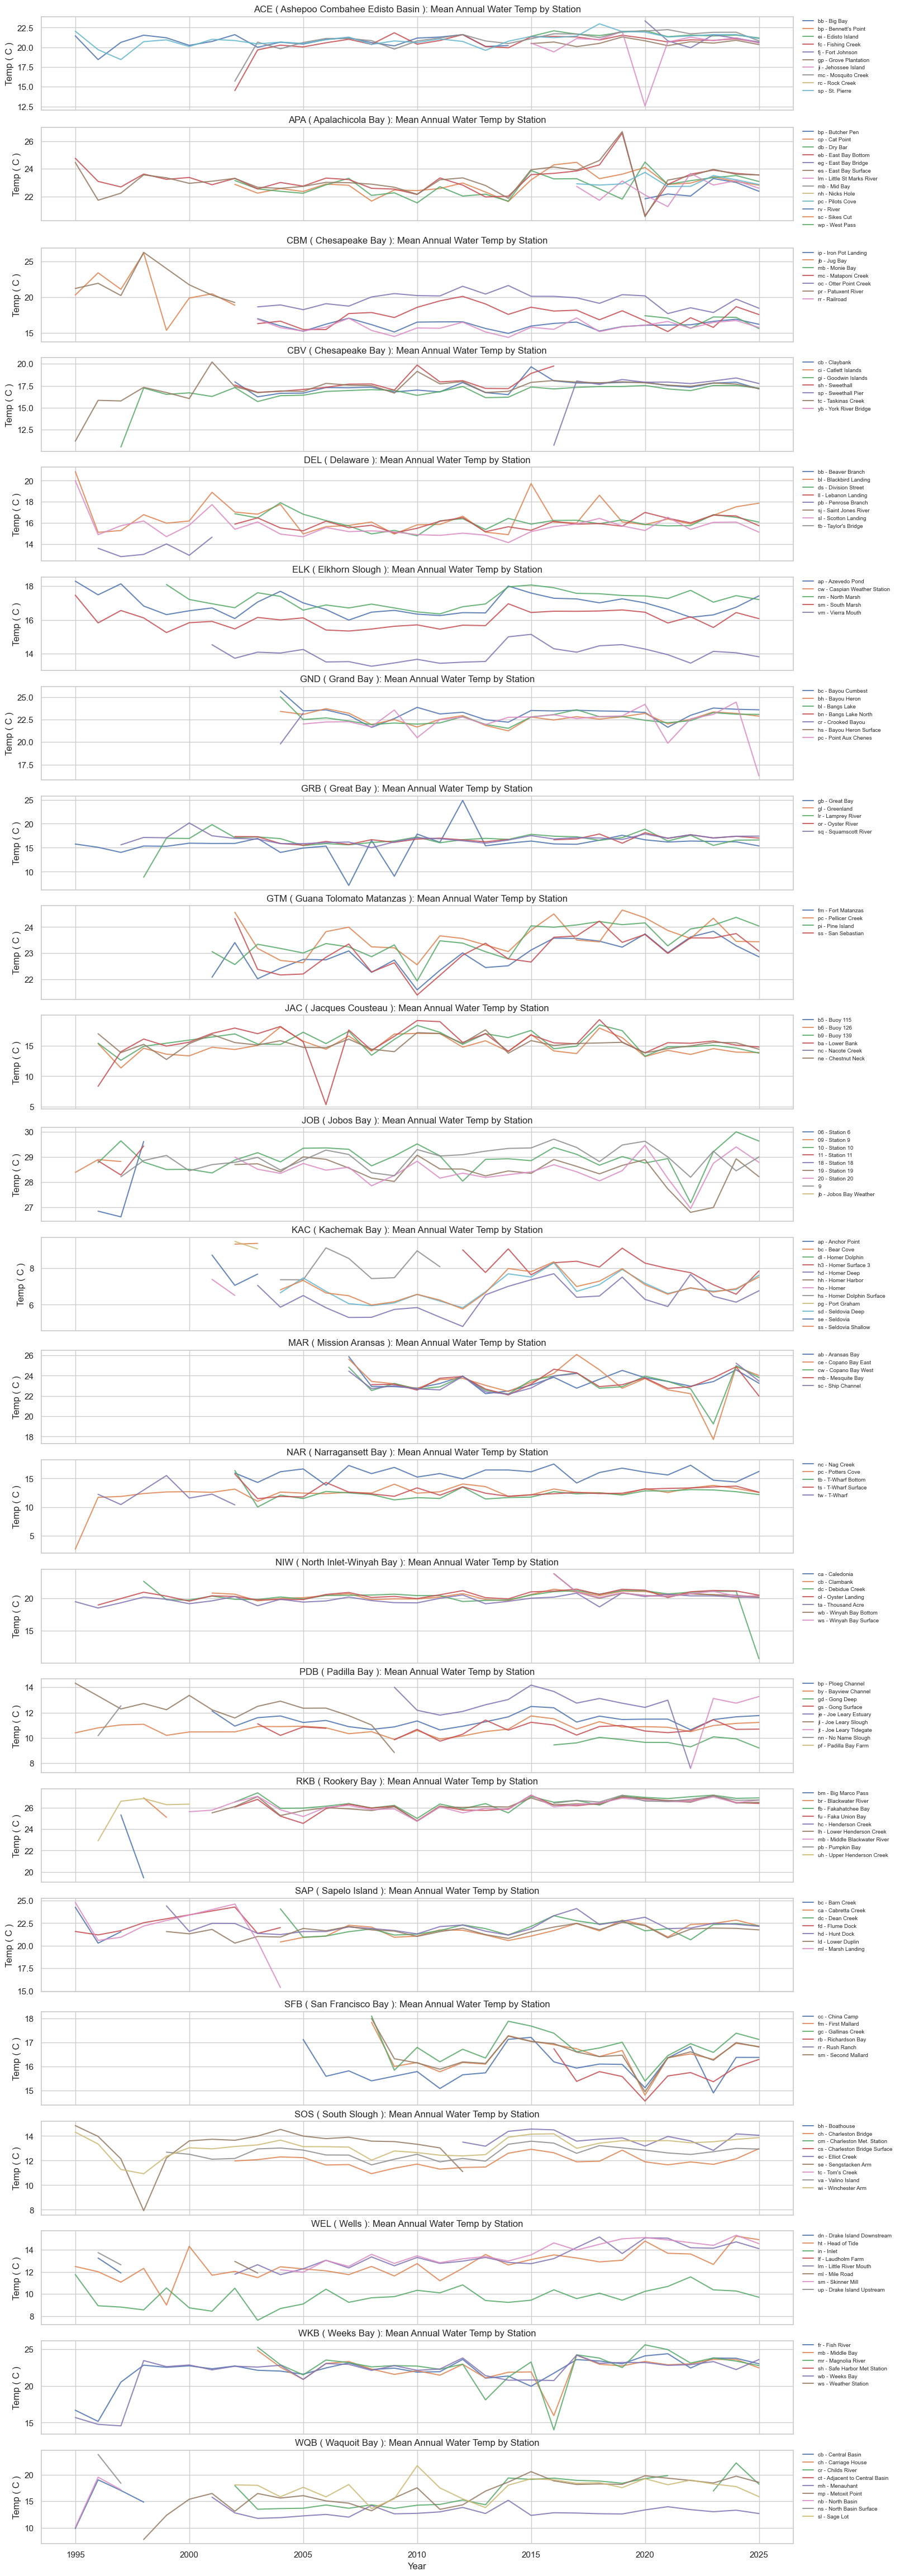

In [ ]:
# tall small-multiples: one subplot per region, one line per station

water[ 'datetime' ] = pd.to_datetime( water[ 'datetime' ], errors = 'coerce' )
water[ 'year' ] = water[ 'datetime' ].dt.year

annual_station = ( 
    water
    .groupby( [ 'region', 'station', 'year' ], as_index = False )[ 'water_temp' ]
    .mean( )
)

regions = sorted( annual_station[ 'region' ].dropna( ).unique( ) )
n_regions = len( regions ) # need for number o'plots

fig, axes = plt.subplots( 
    n_regions,
    1,
    figsize = ( 16, 2 * n_regions ),
    sharex = True,
    constrained_layout = True
)

for ax, region in zip( axes, regions ):
    sub = annual_station.loc[ annual_station[ 'region' ] == region ].sort_values( [ 'station', 'year' ] )

    for station, g in sub.groupby( 'station' ):
        ax.plot( 
            g[ 'year' ],
            g[ 'water_temp' ],
            linewidth = 1.5,
            alpha = 0.85,
            label = station_label( region, station )
        )

    region_title = region_name_lookup.get( region, region )
    ax.set_title( f'{region.upper( )} ( {region_title} ): Mean Annual Water Temp by Station' )
    ax.set_ylabel( 'Temp ( C )' )

    # keep legends readable
    n_stations = sub[ 'station' ].nunique( )

    ax.legend( 
        ncol = 1,
        fontsize = 7,
        frameon = False,
        loc = 'upper left',
        bbox_to_anchor = ( 1.01, 1.0 ),
        borderaxespad = 0
    )

axes[ -1 ].set_xlabel( 'Year' )
plt.show( )

del ( # lil bit of cleanup, for ememory
    annual_station,
    regions,
    n_regions
)

### 1.2 - Domain-Driven KMeans (Temperature, Salinity, Oxygen, Depth)

single slim clustering pass with interpretable station-character features


domain features: ['mean_annual_water_temp', 'seasonal_amp_water_temp', 'mean_annual_salinity', 'seasonal_amp_salinity', 'mean_annual_oxygen', 'seasonal_amp_oxygen', 'mean_annual_depth']

domain-feature k scan:
    k   inertia  silhouette  inertia_drop  inertia_drop_pct
0   2  717.2985      0.2465           NaN               NaN
1   3  558.8742      0.2558      158.4244            0.2209
2   4  468.8886      0.2764       89.9856            0.1610
3   5  393.9863      0.2908       74.9022            0.1597
4   6  351.3629      0.2741       42.6234            0.1082
5   7  308.6914      0.2857       42.6715            0.1214
6   8  274.0403      0.3016       34.6512            0.1123
7   9  245.1399      0.3237       28.9004            0.1055
8  10  216.5935      0.3267       28.5464            0.1164
unbounded silhouette max K: 10
interpretable-window K ( 3-6 ): 5


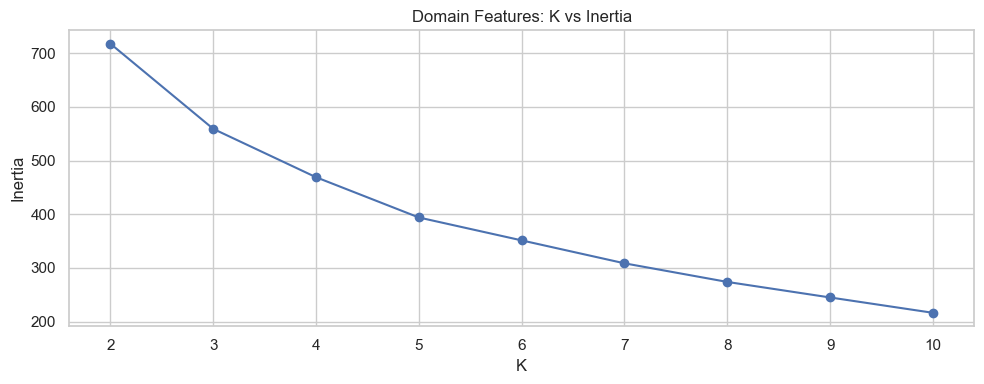

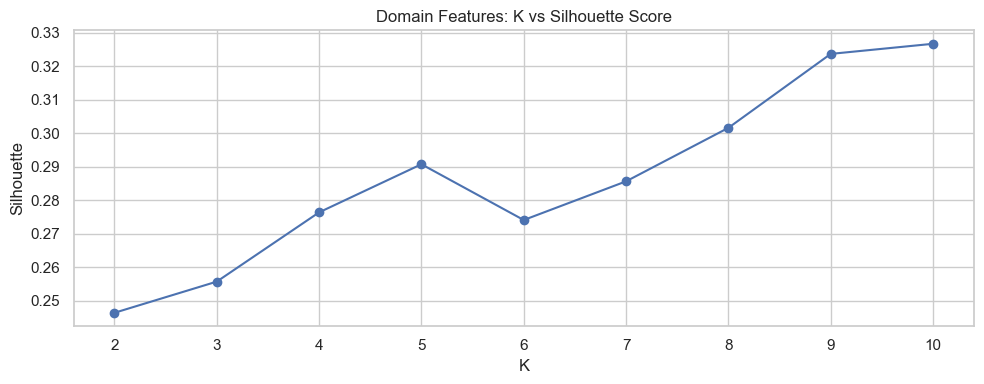

In [51]:
# single, slim KMeans pass with a domain-driven feature subset
# selected features:
# - mean and seasonal amplitude for temperature
# - mean and seasonal amplitude for salinity
# - mean and seasonal amplitude for oxygen
# - mean annual depth
domain_feature_cols = [ 
    'mean_annual_water_temp',
    'seasonal_amp_water_temp',
    'mean_annual_salinity',
    'seasonal_amp_salinity',
    'mean_annual_oxygen',
    'seasonal_amp_oxygen',
    'mean_annual_depth',
]

print( 'domain features:', domain_feature_cols )

domain_input = station_baseline[ [ 'region', 'station' ] + domain_feature_cols ].copy( )

# simple missing-value strategy: region median, then global median
for col in domain_feature_cols:
    domain_input[ col ] = domain_input.groupby( 'region' )[ col ].transform( lambda s: s.fillna( s.median( ) ) )
    domain_input[ col ] = domain_input[ col ].fillna( domain_input[ col ].median( ) )

scaler_domain = StandardScaler( )
X_scaled_domain = scaler_domain.fit_transform( domain_input[ domain_feature_cols ] )

# k scan for elbow + silhouette
k_scan_rows = [ ]

for k in range( 2, 11 ):
    km_scan = KMeans( n_clusters = k, random_state = 42, n_init = 20 )
    labels_scan = km_scan.fit_predict( X_scaled_domain )

    k_scan_rows.append( { 
        'k': k,
        'inertia': float( km_scan.inertia_ ),
        'silhouette': float( silhouette_score( X_scaled_domain, labels_scan ) ),
    } )

k_scan_domain = pd.DataFrame( k_scan_rows )
k_scan_domain[ 'inertia_drop' ] = k_scan_domain[ 'inertia' ].shift( 1 ) - k_scan_domain[ 'inertia' ]
k_scan_domain[ 'inertia_drop_pct' ] = k_scan_domain[ 'inertia_drop' ] / k_scan_domain[ 'inertia' ].shift( 1 )

recommended_k = int( k_scan_domain.loc[ k_scan_domain[ 'silhouette' ].idxmax( ), 'k' ] )

# keep the final pick interpretable for section 1.2
k_min_interpretable = 3
k_max_interpretable = 6
k_scan_interpretable = k_scan_domain.loc[ k_scan_domain[ 'k' ].between( k_min_interpretable, k_max_interpretable ) ].copy( )

if k_scan_interpretable.empty:
    recommended_k_interpretable = 4

else:
    recommended_k_interpretable = int( 
        k_scan_interpretable.loc[ k_scan_interpretable[ 'silhouette' ].idxmax( ), 'k' ]
    )

print( '\ndomain-feature k scan:' )
print( k_scan_domain.round( 4 ) )
print( f'unbounded silhouette max K: { recommended_k }' )
print( f'interpretable-window K ( { k_min_interpretable }-{ k_max_interpretable } ): { recommended_k_interpretable }' )

plt.figure( figsize = ( 10, 4 ) )
plt.plot( k_scan_domain[ 'k' ], k_scan_domain[ 'inertia' ], marker = 'o' )
plt.title( 'Domain Features: K vs Inertia' )
plt.xlabel( 'K' )
plt.ylabel( 'Inertia' )
plt.tight_layout( )
plt.show( )

plt.figure( figsize = ( 10, 4 ) )
plt.plot( k_scan_domain[ 'k' ], k_scan_domain[ 'silhouette' ], marker = 'o' )
plt.title( 'Domain Features: K vs Silhouette Score' )
plt.xlabel( 'K' )
plt.ylabel( 'Silhouette' )
plt.tight_layout( )
plt.show( )

In [55]:
# not a really DISTINCT elbow, but a clear flattening after 4 or 5 clusters, and a silhouette max at 5

# use the bounded recommendation by default; override manually if needed
k_clusters = recommended_k_interpretable
kmeans_model = KMeans( n_clusters = k_clusters, random_state = 42, n_init = 20 )
domain_input[ 'cluster' ] = kmeans_model.fit_predict( X_scaled_domain )

# keep this alias so downstream sections can still use the same naming
domain_input[ 'cluster_domain' ] = domain_input[ 'cluster' ]

domain_silhouette = float( silhouette_score( X_scaled_domain, domain_input[ 'cluster' ] ) )

print( f'\nchosen K: { k_clusters }' )
print( 'domain-feature silhouette:', round( domain_silhouette, 4 ) )

print( '\ncluster sizes:' )
print( domain_input[ 'cluster' ].value_counts( ).sort_index( ) )

cluster_profile_raw = domain_input.groupby( 'cluster' )[ domain_feature_cols ].mean( )
cluster_profile = cluster_profile_raw.round( 3 )

cluster_profile_mean = cluster_profile_raw.mean( )
cluster_profile_std = cluster_profile_raw.std( ddof = 0 ).replace( 0, np.nan )
cluster_profile_z = ( cluster_profile_raw - cluster_profile_mean ) / cluster_profile_std

def bucket_tag( value, low_label, mid_label, high_label, threshold = 0.35 ):
    if pd.isna( value ):
        return mid_label

    if value >= threshold:
        return high_label

    if value <= -threshold:
        return low_label

    return mid_label


def build_cluster_name( z_row ):
    temp_tag = bucket_tag( z_row[ 'mean_annual_water_temp' ], 'Cool', 'Temp', 'Warm' )
    sal_tag = bucket_tag( z_row[ 'mean_annual_salinity' ], 'Fresh', 'Brackish', 'Saline' )
    oxy_tag = bucket_tag( z_row[ 'mean_annual_oxygen' ], 'Low O2', 'Mid O2', 'High O2' )

    amp_tag = bucket_tag( z_row[ 'seasonal_amp_water_temp' ], 'Stable', 'Mixed', 'Seasonal' )
    depth_tag = bucket_tag( z_row[ 'mean_annual_depth' ], 'Shallow', 'Mid', 'Deep' )

    name = f'{ temp_tag } / { sal_tag } / { oxy_tag }'
    short_name = f'{ temp_tag }-{ sal_tag }'
    note = f'{ amp_tag }, { depth_tag }'

    return pd.Series( { 'cluster_name': name, 'cluster_label': short_name, 'cluster_note': note } )


cluster_name_map = cluster_profile_z.apply( build_cluster_name, axis = 1 ).reset_index( )

print( '\ncluster names:' )
print( cluster_name_map )


chosen K: 5
domain-feature silhouette: 0.2908

cluster sizes:
cluster
0    37
1    57
2    24
3    13
4     3
Name: count, dtype: int64

cluster names:
   cluster               cluster_name  cluster_label       cluster_note
0        0     Temp / Fresh / High O2     Temp-Fresh  Seasonal, Shallow
1        1      Warm / Fresh / Low O2     Warm-Fresh  Seasonal, Shallow
2        2  Cool / Brackish / High O2  Cool-Brackish    Stable, Shallow
3        3     Warm / Saline / Low O2    Warm-Saline    Stable, Shallow
4        4    Cool / Saline / High O2    Cool-Saline       Stable, Deep


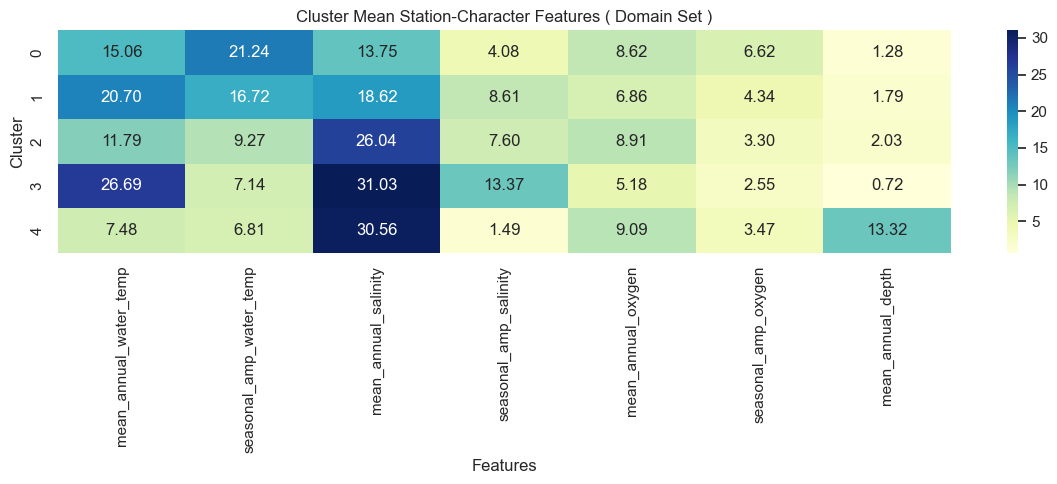

In [56]:
# keep labels categorical and ordered by cluster id for readability + compact memory
cluster_order = sorted( cluster_name_map[ 'cluster' ].astype( int ).tolist( ) )
cluster_name_order = cluster_name_map.sort_values( 'cluster' )[ 'cluster_name' ].tolist( )
cluster_label_order = cluster_name_map.sort_values( 'cluster' )[ 'cluster_label' ].tolist( )

domain_input = domain_input.merge( cluster_name_map, on = 'cluster', how = 'left' )

# write cluster labels back to the station tables
for cluster_col in [ 'cluster', 'cluster_domain', 'cluster_name', 'cluster_label', 'cluster_note' ]:
    if cluster_col in station_baseline.columns:
        station_baseline = station_baseline.drop( columns = [ cluster_col ] )

station_baseline = station_baseline.merge( 
    domain_input[ [ 'region', 'station', 'cluster', 'cluster_domain', 'cluster_name', 'cluster_label', 'cluster_note' ] ],
    on = [ 'region', 'station' ],
    how = 'left',
)

station_baseline[ 'cluster' ] = pd.Categorical( 
    station_baseline[ 'cluster' ],
    categories = cluster_order,
    ordered = True,
)
station_baseline[ 'cluster_name' ] = pd.Categorical( 
    station_baseline[ 'cluster_name' ],
    categories = cluster_name_order,
    ordered = True,
)
station_baseline[ 'cluster_label' ] = pd.Categorical( 
    station_baseline[ 'cluster_label' ],
    categories = cluster_label_order,
    ordered = True,
)

for cluster_col in [ 'cluster', 'cluster_domain', 'cluster_name', 'cluster_label', 'cluster_note' ]:
    if cluster_col in station_baseline_display.columns:
        station_baseline_display = station_baseline_display.drop( columns = [ cluster_col ] )

station_baseline_display = station_baseline_display.merge( 
    domain_input[ [ 'region', 'station', 'cluster', 'cluster_domain', 'cluster_name', 'cluster_label', 'cluster_note' ] ],
    on = [ 'region', 'station' ],
    how = 'left',
)

# cluster mean feature profiles
plt.figure( figsize = ( 12, 5 ) )
sns.heatmap( cluster_profile, cmap = 'YlGnBu', annot = True, fmt = '.2f' )
plt.title( 'Cluster Mean Station-Character Features ( Domain Set )' )
plt.xlabel( 'Features' )
plt.ylabel( 'Cluster' )
plt.tight_layout( )
plt.show( )

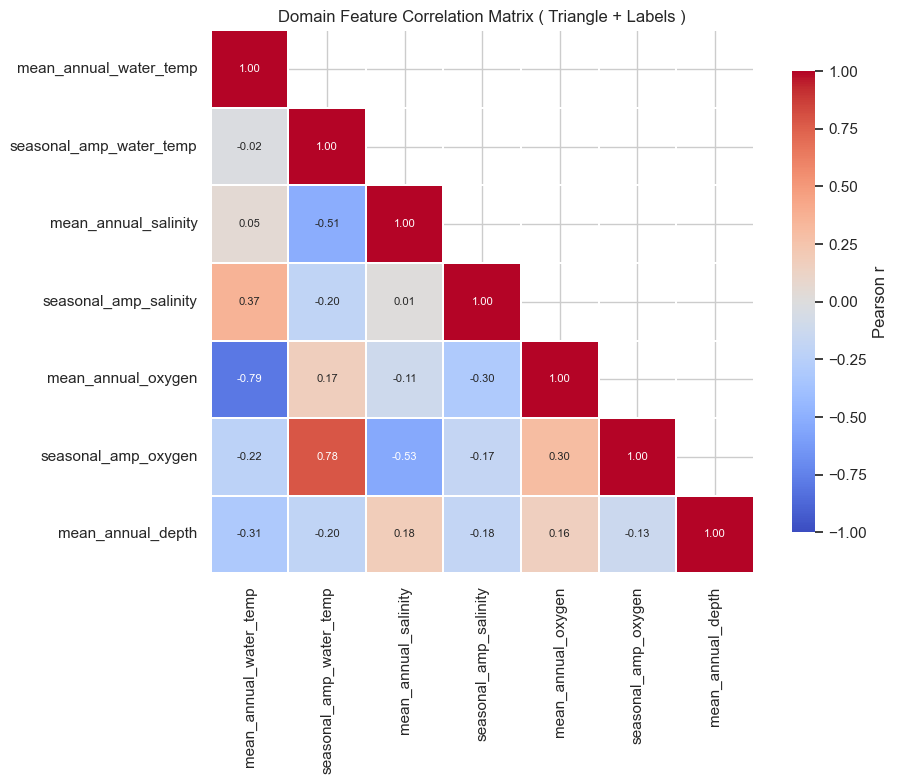

In [57]:
# correlation matrix for the domain feature set
feature_corr_domain = domain_input[ domain_feature_cols ].corr( )
tri_mask = np.triu( np.ones_like( feature_corr_domain, dtype = bool ), k = 1 )

plt.figure( figsize = ( 10, 8 ) )
sns.heatmap( 
    feature_corr_domain,
    mask = tri_mask,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0,
    vmin = -1,
    vmax = 1,
    square = True,
    linewidths = 0.35,
    annot_kws = { 'size': 8 },
    cbar_kws = { 'label': 'Pearson r', 'shrink': 0.85 },
)
plt.title( 'Domain Feature Correlation Matrix ( Triangle + Labels )' )
plt.tight_layout( )
plt.show( )


top correlated domain-feature pairs:


<Axes: xlabel='pc1', ylabel='pc2'>

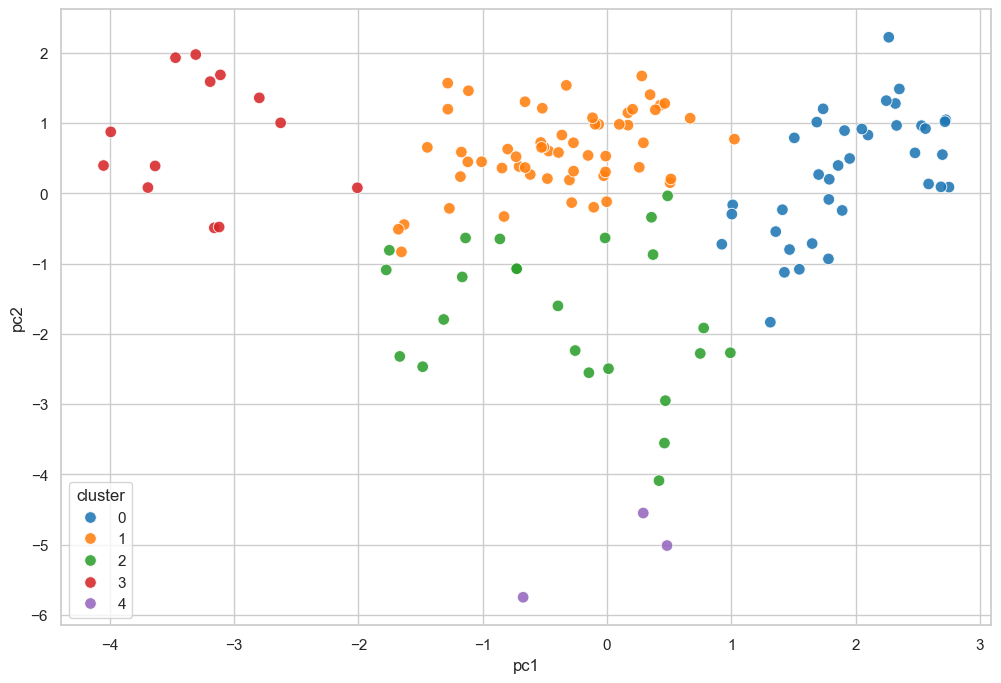

In [58]:
corr_pairs_domain = ( 
    feature_corr_domain
    .where( np.triu( np.ones( feature_corr_domain.shape ), k = 1 ).astype( bool ) )
    .stack( )
    .reset_index( )
    .rename( columns = { 'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'corr' } )
)

corr_pairs_domain[ 'abs_corr' ] = corr_pairs_domain[ 'corr' ].abs( )
corr_pairs_domain = corr_pairs_domain.sort_values( 'abs_corr', ascending = False )

print( '\ntop correlated domain-feature pairs:' )
corr_pairs_domain.head( 12 )

# PCA scatter of resulting clusters
pca_domain = PCA( n_components = 2 )
pcs_domain = pca_domain.fit_transform( X_scaled_domain )

pca_loadings_domain = pd.DataFrame( 
    pca_domain.components_.T,
    index = domain_feature_cols,
    columns = [ 'PC1', 'PC2' ],
)

# for eventual readability 
feature_phrase_map = { 
    'mean_annual_water_temp': ( 'warmer mean temp', 'cooler mean temp' ),
    'seasonal_amp_water_temp': ( 'larger temp seasonality', 'smaller temp seasonality' ),
    'mean_annual_salinity': ( 'saltier water', 'fresher water' ),
    'seasonal_amp_salinity': ( 'larger salinity swings', 'smaller salinity swings' ),
    'mean_annual_oxygen': ( 'higher mean oxygen', 'lower mean oxygen' ),
    'seasonal_amp_oxygen': ( 'larger oxygen swings', 'smaller oxygen swings' ),
    'mean_annual_depth': ( 'deeper stations', 'shallower stations' ),
}


# automate, if at all possible, interpreting the PCAs


def pc_axis_interpretation( component_name ):
    top_features = pca_loadings_domain[ component_name ].abs( ).sort_values( ascending = False ).head( 2 ).index
    text_parts = [ ]

    for feat in top_features:
        pos_text, neg_text = feature_phrase_map[ feat ]
        loading = pca_loadings_domain.loc[ feat, component_name ]
        text_parts.append( pos_text if loading >= 0 else neg_text )

    return ' + '.join( text_parts )


pc1_var_pct = round( float( pca_domain.explained_variance_ratio_[ 0 ] ) * 100, 1 )
pc2_var_pct = round( float( pca_domain.explained_variance_ratio_[ 1 ] ) * 100, 1 )
pc1_label_text = pc_axis_interpretation( 'PC1' )
pc2_label_text = pc_axis_interpretation( 'PC2' )

domain_plot = domain_input[ [ 'region', 'station', 'cluster', 'cluster_name', 'cluster_label', 'cluster_note' ] ].copy( )
domain_plot[ 'pc1' ] = pcs_domain[ :, 0 ]
domain_plot[ 'pc2' ] = pcs_domain[ :, 1 ]

cluster_centers = ( 
    domain_plot
    .groupby( [ 'cluster', 'cluster_name', 'cluster_label', 'cluster_note' ], as_index = False )[ [ 'pc1', 'pc2' ] ]
    .mean( )
)

plt.figure( figsize = ( 12, 8 ) )
sns.scatterplot( 
    data = domain_plot,
    x = 'pc1',
    y = 'pc2',
    hue = 'cluster',
    palette = 'tab10',
    s = 70,
    alpha = 0.88,
)


In [62]:
# just wanna see soem examples
station_baseline_display[ [ 
    'region',
    'station',
    'station_name',
    'cluster',
    'cluster_name',
    'cluster_label',
    'cluster_note',
    'baseline_start_year',
    'baseline_end_year',
    'n_valid_years',
] ].sort_values( [ 'cluster', 'region', 'station' ] ).sample( 7 ).T

,117,49,22,111,78,20,88
region,sos,gtm,cbv,sfb,nar,cbm,pdb
station,va,pc,cb,sm,ts,oc,gd
station_name,Valino Island,Pellicer Creek,Claybank,Second Mallard,T-Wharf Surface,Otter Point Creek,Gong Deep
cluster,2,1,0,1,0,0,4
cluster_name,Cool / Brackish / High O2,Warm / Fresh / Low O2,Temp / Fresh / High O2,Warm / Fresh / Low O2,Temp / Fresh / High O2,Temp / Fresh / High O2,Cool / Saline / High O2
cluster_label,Cool-Brackish,Warm-Fresh,Temp-Fresh,Warm-Fresh,Temp-Fresh,Temp-Fresh,Cool-Saline
cluster_note,"Stable, Shallow","Seasonal, Shallow","Seasonal, Shallow","Seasonal, Shallow","Seasonal, Shallow","Seasonal, Shallow","Stable, Deep"
baseline_start_year,2000,2002,2002,2008,2003,2004,2017
baseline_end_year,2004,2006,2006,2012,2007,2008,2021
n_valid_years,5,5,5,5,5,5,5


#### PCA Interpretation (Domain Feature Set)

- **PC1** and **PC2** are weighted blends of the selected domain features.
- Use **explained variance ratio** to see how much structure each component captures.
- Use **absolute loadings** to identify which features dominate each component.
- Nearby points in PCA space still represent similar station character.


In [63]:
# quick PCA interpretation table for the domain feature run
pca_variance = pd.Series( 
    pca_domain.explained_variance_ratio_,
    index = [ f'PC{i+1}' for i in range( len( pca_domain.explained_variance_ratio_ ) ) ],
    name = 'explained_variance_ratio',
)

pca_loadings = pd.DataFrame( 
    pca_domain.components_.T,
    index = domain_feature_cols,
    columns = [ f'PC{i+1}' for i in range( pca_domain.n_components_ ) ],
)

print( 'explained variance ratio:' )
print( pca_variance.round( 3 ) )

pca_loadings.round( 3 )

explained variance ratio:
PC1    0.367
PC2    0.278
Name: explained_variance_ratio, dtype: float64


,PC1,PC2
mean_annual_water_temp,-0.365,0.498
seasonal_amp_water_temp,0.462,0.356
mean_annual_salinity,-0.369,-0.346
seasonal_amp_salinity,-0.283,0.278
mean_annual_oxygen,0.412,-0.393
seasonal_amp_oxygen,0.517,0.256
mean_annual_depth,0.004,-0.457


### 1.3 - Cluster Context and Distribution

prepare cluster-station context and inspect distribution by region


In [ ]:
# 1.3 - cluster context check with available station metadata
# keep a clean station-level table for context and distribution checks

cluster_station = station_baseline_display.copy( )

# fallback labels in case this cell is run before 1.2 naming is created
if 'cluster_name' not in cluster_station.columns:
    cluster_station[ 'cluster_name' ] = 'Cluster ' + cluster_station[ 'cluster' ].astype( str )

if 'cluster_note' not in cluster_station.columns:
    cluster_station[ 'cluster_note' ] = ''

cluster_station[ 'latitude' ] = pd.to_numeric( cluster_station[ 'latitude' ], errors = 'coerce' )
cluster_station[ 'longitude' ] = pd.to_numeric( cluster_station[ 'longitude' ], errors = 'coerce' )

cluster_distribution_region = pd.crosstab( 
    cluster_station[ 'region' ],
    cluster_station[ 'cluster' ],
)

print( 'cluster distribution by region:' )
cluster_distribution_region

plt.figure( figsize = ( 10, 6 ) )
sns.heatmap( cluster_distribution_region, annot = True, fmt = 'd', cmap = 'Blues' )
plt.title( 'Cluster Distribution by Region' )
plt.xlabel( 'Cluster' )
plt.ylabel( 'Region' )
plt.tight_layout( )
plt.show( )


### 1.4 - Assign Regime Labels to the Working Dataset (Slim Join)

add only the cluster id to the large working table, and keep descriptive labels in small lookup tables


In [ ]:
# 1.4 - slim cluster assignment to the large working table
# keep it lean: only add cluster id to water, keep descriptive labels in small lookup tables

station_cluster_lookup = ( 
    station_baseline[ [ 'region', 'station', 'cluster' ] ]
    .drop_duplicates( )
    .sort_values( [ 'region', 'station' ] )
    .reset_index( drop = True )
)

cluster_label_lookup = ( 
    station_baseline[ [ 'cluster', 'cluster_name', 'cluster_label', 'cluster_note' ] ]
    .drop_duplicates( subset = [ 'cluster' ] )
    .sort_values( 'cluster' )
    .reset_index( drop = True )
)

# save the small lookup tables for reproducibility
station_cluster_lookup_path = '../data/reference/t4d.station_cluster.lookup.csv'
cluster_label_lookup_path = '../data/reference/t4d.cluster_label.lookup.csv'

station_cluster_lookup.to_csv( station_cluster_lookup_path, index = False )
cluster_label_lookup.to_csv( cluster_label_lookup_path, index = False )

# add only cluster id to the large water table
if 'cluster' in water.columns:
    water = water.drop( columns = [ 'cluster' ] )

water = water.merge( station_cluster_lookup, on = [ 'region', 'station' ], how = 'left' )

n_rows = len( water )
n_clustered = int( water[ 'cluster' ].notna( ).sum( ) )
cluster_coverage = round( 100 * n_clustered / n_rows, 2 ) if n_rows > 0 else np.nan

water_memory_mb = round( water.memory_usage( deep = True ).sum( ) / 1024 / 1024, 2 )

print( f'water rows with cluster assigned: {n_clustered} / {n_rows} ( {cluster_coverage}% )' )
print( f'current water table size (MB): {water_memory_mb}' )
print( f'saved: {station_cluster_lookup_path}' )
print( f'saved: {cluster_label_lookup_path}' )

print( )
print( 'cluster label lookup:' )
cluster_label_lookup

### 1.5 - Map Stations by Regime

plot station locations colored by cluster, with rough land/ocean contours when available


In [ ]:
# 1.5 - map stations by cluster (static matplotlib)
import geopandas as gpd
import pyogrio

# keep this cell self-contained so visualization cells can be reordered safely
map_source = station_baseline_display.copy( )

if ( 'latitude' not in map_source.columns ) or ( 'longitude' not in map_source.columns ):
    map_source = map_source.merge( 
        station_lookup[ [ 'region', 'station', 'latitude', 'longitude' ] ],
        on = [ 'region', 'station' ],
        how = 'left',
    )

map_source[ 'latitude' ] = pd.to_numeric( map_source[ 'latitude' ], errors = 'coerce' )
map_source[ 'longitude' ] = pd.to_numeric( map_source[ 'longitude' ], errors = 'coerce' )

map_df = map_source.dropna( subset = [ 'latitude', 'longitude', 'cluster' ] ).copy( )

cluster_ids = sorted( map_df[ 'cluster' ].dropna( ).astype( int ).unique( ) )
palette = sns.color_palette( 'tab10', n_colors = max( len( cluster_ids ), 1 ) )
cluster_color_map = { cid: palette[ idx % len( palette ) ] for idx, cid in enumerate( cluster_ids ) }

center_df = ( 
    map_df
    .groupby( [ 'cluster', 'cluster_label' ], as_index = False )[ [ 'longitude', 'latitude' ] ]
    .mean( )
)

cluster_label_map = ( 
    center_df
    .drop_duplicates( subset = [ 'cluster' ] )
    .set_index( 'cluster' )[ 'cluster_label' ]
    .to_dict( )
)

lon_min = map_df[ 'longitude' ].min( )
lon_max = map_df[ 'longitude' ].max( )
lat_min = map_df[ 'latitude' ].min( )
lat_max = map_df[ 'latitude' ].max( )

lon_pad = max( 1.5, ( lon_max - lon_min ) * 0.12 )
lat_pad = max( 1.0, ( lat_max - lat_min ) * 0.12 )

fig, ax = plt.subplots( figsize = ( 12, 7 ) )
ax.set_facecolor( '#d7ecff' )

# find a local Natural Earth shapefile path robustly
ne_path = None
ne_candidates = [ 
    Path( pyogrio.__file__ ).resolve( ).parent / 'tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp',
    Path( '../data/reference/naturalearth_lowres.shp' ),
]

for candidate in ne_candidates:
    if candidate.exists( ):
        ne_path = candidate
        break

if ne_path is not None:
    world = gpd.read_file( ne_path )

    world.plot( 
        ax = ax,
        color = '#f2efe4',
        edgecolor = 'none',
        zorder = 0,
    )

    world.boundary.plot( 
        ax = ax,
        color = '#666666',
        linewidth = 0.45,
        zorder = 1,
    )

else:
    print( 'map background skipped: no Natural Earth shapefile found' )

for cid in cluster_ids:
    sub = map_df.loc[ map_df[ 'cluster' ] == cid ]

    ax.scatter( 
        sub[ 'longitude' ],
        sub[ 'latitude' ],
        s = 70,
        alpha = 0.88,
        color = cluster_color_map[ cid ],
        label = str( cluster_label_map.get( cid, f'Cluster {cid}' ) ),
        zorder = 2,
    )

for _, row in center_df.iterrows( ):
    ax.text( 
        row[ 'longitude' ],
        row[ 'latitude' ],
        str( row[ 'cluster_label' ] ),
        fontsize = 7,
        ha = 'center',
        va = 'center',
        bbox = { 
            'boxstyle': 'round,pad=0.25',
            'facecolor': 'white',
            'alpha': 0.75,
            'edgecolor': 'gray',
        },
        zorder = 3,
    )

ax.set_xlim( lon_min - lon_pad, lon_max + lon_pad )
ax.set_ylim( lat_min - lat_pad, lat_max + lat_pad )
ax.set_xlabel( 'Longitude' )
ax.set_ylabel( 'Latitude' )
ax.set_title( 'Station Map by Cluster ( Static Map + Coastlines )' )
ax.legend( 
    title = 'Regime',
    loc = 'lower left',
    frameon = True,
)

plt.tight_layout( )
plt.show( )

### 1.6 - Reference Tables for Reporting

commit cluster summary and station tables to small reference objects/files


In [ ]:
# 1.6 - save reference tables for reporting
cluster_station[ 'latitude' ] = pd.to_numeric( cluster_station[ 'latitude' ], errors = 'coerce' )
cluster_station[ 'longitude' ] = pd.to_numeric( cluster_station[ 'longitude' ], errors = 'coerce' )

cluster_specs = ( 
    cluster_station
    .groupby( 'cluster', as_index = False )
    .agg( # gather the following specs for each station cluster: (see kmeans earlier)
        cluster_name = ( 'cluster_name', 'first' ),
        cluster_label = ( 'cluster_label', 'first' ),
        cluster_note = ( 'cluster_note', 'first' ),
        n_stations = ( 'station', 'nunique' ),
        n_regions = ( 'region', 'nunique' ),
        mean_annual_water_temp = ( 'mean_annual_water_temp', 'mean' ),
        seasonal_amp_water_temp = ( 'seasonal_amp_water_temp', 'mean' ),
        mean_annual_salinity = ( 'mean_annual_salinity', 'mean' ),
        seasonal_amp_salinity = ( 'seasonal_amp_salinity', 'mean' ),
        mean_annual_oxygen = ( 'mean_annual_oxygen', 'mean' ),
        seasonal_amp_oxygen = ( 'seasonal_amp_oxygen', 'mean' ),
        mean_annual_depth = ( 'mean_annual_depth', 'mean' ),
        mean_latitude = ( 'latitude', 'mean' ),
        mean_longitude = ( 'longitude', 'mean' ),
    )
    .sort_values( 'cluster' )
    .reset_index( drop = True )
)

# a tad more readable ... 
for col in [ 
    'mean_annual_water_temp',
    'seasonal_amp_water_temp',
    'mean_annual_salinity',
    'seasonal_amp_salinity',
    'mean_annual_oxygen',
    'seasonal_amp_oxygen',
    'mean_annual_depth',
    'mean_latitude',
    'mean_longitude',
]:
    cluster_specs[ col ] = cluster_specs[ col ].round( 3 )

cluster_station_table = cluster_station[ [ 
    'region',
    'region_name',
    'station',
    'station_name',
    'latitude',
    'longitude',
    'cluster',
    'cluster_name',
    'cluster_label',
    'cluster_note',
] ].sort_values( [ 'cluster', 'region', 'station' ] )

# caching the cluster specifications as a reference guide later
# if we reconfigure anyhting about the k-means work, will have to delete these
cluster_specs_path = '../data/reference/t4d.domain.cluster.specs.csv'
cluster_station_table_path = '../data/reference/t4d.cluster.station.table.csv'

cluster_specs.to_csv( cluster_specs_path, index = False )
cluster_station_table.to_csv( cluster_station_table_path, index = False )

#print( f'saved: {cluster_specs_path}' )
#print( f'saved: {cluster_station_table_path}' )

print( 'station table sample:' )
cluster_station_table.sample( 10 ).round( 3 )

## Phase 2 — Temporal Diagnostics
Goal: characterize lag structure and trends before building predictive features

- 2.1 run STL decomposition on water temperature per station
  - see: https://www.youtube.com/watch?v=1NXryMoU7Ho
  - annual + diurnal cycles 
  - extract trend components
  - see trends analysis for example
- 2.2 compute cross-correlations between air temp and water temp across a range of lags (0–28 days)
  - identify lag-at-peak-correlation per station
- 2.3 repeat cross-correlation for wind/precip → salinity, air temp → DO
  - reading suggests DO may be longer lag times
- 2.4 summarize lag structure by regime
  - do cold estuaries respond more slowly than warm ones?
  - other oddities? 
  - stuff we'd report on in paper/poster
- 2.5 identify stations showing trend drift in the STL trend component
  - lag candidates for regime-transition analysis
  - feeds into phase 5, btw...

In [ ]:
# helper function to find best lag correlation for a given driver-response pair


def best_lag_table( daily_df, driver_col, response_col, lag_max = 28, min_pairs = 40 ):
    rows = [ ]

    for ( region, station ), g in daily_df.groupby( [ 'region', 'station' ] ):
        s = g.sort_values( 'date' ).set_index( 'date' )

        driver = s[ driver_col ]
        response = s[ response_col ]

        best_lag = np.nan
        best_corr = np.nan
        best_n = 0

        for lag in range( lag_max + 1 ):
            # lag means driver leads response by `lag` days
            pair = pd.concat( [ response, driver.shift( lag ) ], axis = 1 ).dropna( )

            if len( pair ) < min_pairs:
                continue

            # how strongly do they align?
            corr = pair.iloc[ :, 0 ].corr( pair.iloc[ :, 1 ] )

            if pd.isna( corr ):
                continue

            # hold on to the strong correlation
            if pd.isna( best_corr ) or abs( corr ) > abs( best_corr ):
                best_lag = lag
                best_corr = corr
                best_n = len( pair )

        # save it
        rows.append( { 
            'region': region,
            'station': station,
            'best_lag_days': best_lag,
            'peak_corr': best_corr,
            'n_pairs': best_n,
        } )

    out = pd.DataFrame( rows )

    out = out.merge( 
        daily_df[ [ 'region', 'station', 'cluster' ] ].drop_duplicates( ),
        on = [ 'region', 'station' ],
        how = 'left',
    )

    return out

In [ ]:
# 2.1 - temporal diagnostics (first working pass)
# simple outputs: daily_air diagnostics + STL trend summary + lag-at-peak-correlation tables
from pathlib import Path
from statsmodels.tsa.seasonal import STL

phase2_out_dir = '../data/reference/phase2'
Path( phase2_out_dir ).mkdir( parents = True, exist_ok = True )

# this is a bit of work so the results will be cached to file and checked
# for if more runs are done that don't need to redo this
# to redo it... delete the cache files
daily_cache_path = f'{phase2_out_dir}/t4d.phase2.daily.csv'
stl_summary_path = f'{phase2_out_dir}/t4d.phase2.stl.summary.csv'
lag_air_to_water_path = f'{phase2_out_dir}/t4d.phase2.lag.air_to_water.csv'
lag_wind_to_salinity_path = f'{phase2_out_dir}/t4d.phase2.lag.wind_to_salinity.csv'
lag_precip_to_salinity_path = f'{phase2_out_dir}/t4d.phase2.lag.precip_to_salinity.csv'
lag_air_to_oxygen_path = f'{phase2_out_dir}/t4d.phase2.lag.air_to_oxygen.csv'
lag_cluster_summary_path = f'{phase2_out_dir}/t4d.phase2.lag.cluster.summary.csv'
trend_drift_candidates_path = f'{phase2_out_dir}/t4d.phase2.trend.drift.candidates.csv'

core_cache_paths = [ 
    daily_cache_path,
    stl_summary_path,
    lag_air_to_water_path,
    lag_wind_to_salinity_path,
    lag_precip_to_salinity_path,
    lag_air_to_oxygen_path,
]

# basically.. it took about 10 min per run,
# and that's a long time to wait just to change a font in a chart later...
phase2_cache_loaded = all( [ Path( fp ).exists( ) for fp in core_cache_paths ] )
if phase2_cache_loaded:
    print( 'loading cached phase 2 tables before recompute...' )

    daily_air = pd.read_csv( daily_cache_path )
    daily_air[ 'date' ] = pd.to_datetime( daily_air[ 'date' ], errors = 'coerce' )

    stl_summary = pd.read_csv( stl_summary_path )
    lag_air_to_water = pd.read_csv( lag_air_to_water_path )
    lag_wind_to_salinity = pd.read_csv( lag_wind_to_salinity_path )
    lag_precip_to_salinity = pd.read_csv( lag_precip_to_salinity_path )
    lag_air_to_oxygen = pd.read_csv( lag_air_to_oxygen_path )

    if Path( lag_cluster_summary_path ).exists( ):
        lag_cluster_summary = pd.read_csv( lag_cluster_summary_path )

    if Path( trend_drift_candidates_path ).exists( ):
        trend_drift_candidates = pd.read_csv( trend_drift_candidates_path )

    print( 'cached row counts:' )
    print( 'daily rows:', len( daily_air ) )
    print( 'stl summary:', len( stl_summary ) )
    print( 'air -> water lag:', len( lag_air_to_water ) )
    print( 'wind -> salinity lag:', len( lag_wind_to_salinity ) )
    print( 'precip -> salinity lag:', len( lag_precip_to_salinity ) )
    print( 'air -> oxygen lag:', len( lag_air_to_oxygen ) )

else:
    print( 'phase 2 cache not complete; computing fresh outputs...' )

    phase2 = water.copy( )
    phase2[ 'datetime' ] = pd.to_datetime( phase2[ 'datetime' ], errors = 'coerce' )
    phase2 = phase2.dropna( subset = [ 'datetime' ] )

    # fix air temperature column naming from raw files if needed
    if 'air_temp' not in phase2.columns:
        if 'm_temp_c' in phase2.columns:
            phase2[ 'air_temp' ] = phase2[ 'm_temp_c' ]

    # make sure we have cluster on each row
    if 'cluster' not in phase2.columns:
        phase2 = phase2.merge( 
            station_baseline[ [ 'region', 'station', 'cluster' ] ].drop_duplicates( ),
            on = [ 'region', 'station' ],
            how = 'left',
        )

    phase2[ 'date' ] = phase2[ 'datetime' ].dt.floor( 'D' )

    daily_air = ( 
        phase2
        .groupby( [ 'region', 'station', 'cluster', 'date' ], as_index = False )
        .agg( 
            water_temp_daily = ( 'water_temp', 'mean' ),
            salinity_daily = ( 'salinity', 'mean' ),
            oxygen_daily = ( 'oxygen', 'mean' ),
            air_temp_daily = ( 'air_temp', 'mean' ),
            wind_speed_daily = ( 'wind_speed', 'mean' ),
            precip_daily = ( 'precipitation', 'sum' ),
        )
    )

    print( 'daily diagnostic rows:', len( daily_air ) )
    daily_air.to_csv( daily_cache_path, index = False )

    # 2.1 STL on daily water temperature (annual cycle)
    # see https://www.youtube.com/watch?v=1NXryMoU7Ho
    stl_rows = [ ]

    for ( region, station ), g in daily_air.groupby( [ 'region', 'station' ] ):
        s = g.sort_values( 'date' ).set_index( 'date' )[ 'water_temp_daily' ]

        # regular daily index so STL has a stable cadence
        full_idx = pd.date_range( s.index.min( ), s.index.max( ), freq = 'D' )
        s = s.reindex( full_idx )

        if s.notna( ).sum( ) < 365:
            continue

        s = s.interpolate( limit_direction = 'both' )

        if s.notna( ).sum( ) < 365:
            continue

        # reminder .. STL is seasonal trend decomposition based on LOESS smoothing
        # it's robust to outliers and can handle some missing data
        # but it does require a regular time index and enough data to identify the seasonal pattern
        stl = STL( s, period = 365, robust = True ).fit( )

        trend = stl.trend
        slope_per_day = np.polyfit( np.arange( len( trend ) ), trend, 1 )[ 0 ]
        slope_per_year = slope_per_day * 365

        stl_rows.append( { 
            'region': region,
            'station': station,
            'cluster': g[ 'cluster' ].dropna( ).iloc[ 0 ] if g[ 'cluster' ].notna( ).any( ) else np.nan,
            'n_days': int( len( s ) ),
            'stl_trend_slope_c_per_year': float( slope_per_year ),
            'stl_seasonal_amp_c': float( stl.seasonal.max( ) - stl.seasonal.min( ) ),
        } )

    stl_summary = pd.DataFrame( stl_rows )
    print( 'stl station count:', len( stl_summary ) )

### 2.2 and 2.3 - build lag tables

In [ ]:
# 2.2 and 2.3 lag tables (with cache)
# don't redo this work if it's done
# but if you WANT to, then you'll have to clean the files out physically and rerun
if phase2_cache_loaded:
    print( 'using lag tables already loaded from cache in 2.1' )

else:
    phase2_out_dir = '../data/reference/phase2'
    Path( phase2_out_dir ).mkdir( parents = True, exist_ok = True )

    lag_air_to_water_path = f'{phase2_out_dir}/t4d.phase2.lag.air_to_water.csv'
    lag_wind_to_salinity_path = f'{phase2_out_dir}/t4d.phase2.lag.wind_to_salinity.csv'
    lag_precip_to_salinity_path = f'{phase2_out_dir}/t4d.phase2.lag.precip_to_salinity.csv'
    lag_air_to_oxygen_path = f'{phase2_out_dir}/t4d.phase2.lag.air_to_oxygen.csv'

    lag_paths = [ 
        lag_air_to_water_path,
        lag_wind_to_salinity_path,
        lag_precip_to_salinity_path,
        lag_air_to_oxygen_path,
    ]

    if all( [ Path( fp ).exists( ) for fp in lag_paths ] ):
        print( 'loading cached lag tables from disk...' )

        lag_air_to_water = pd.read_csv( lag_air_to_water_path )
        lag_wind_to_salinity = pd.read_csv( lag_wind_to_salinity_path )
        lag_precip_to_salinity = pd.read_csv( lag_precip_to_salinity_path )
        lag_air_to_oxygen = pd.read_csv( lag_air_to_oxygen_path )

    else:
        print( 'lag cache not found; computing lag tables...' )

        # defined up above
        # rinse and repeat
        lag_air_to_water = best_lag_table( daily_air, 'air_temp_daily', 'water_temp_daily', lag_max = 28 )
        lag_wind_to_salinity = best_lag_table( daily_air, 'wind_speed_daily', 'salinity_daily', lag_max = 28 )
        lag_precip_to_salinity = best_lag_table( daily_air, 'precip_daily', 'salinity_daily', lag_max = 28 )
        lag_air_to_oxygen = best_lag_table( daily_air, 'air_temp_daily', 'oxygen_daily', lag_max = 28 )

        lag_air_to_water.to_csv( lag_air_to_water_path, index = False )
        lag_wind_to_salinity.to_csv( lag_wind_to_salinity_path, index = False )
        lag_precip_to_salinity.to_csv( lag_precip_to_salinity_path, index = False )
        lag_air_to_oxygen.to_csv( lag_air_to_oxygen_path, index = False )

print( )
print( 'lag table row counts:' )
print( 'air -> water:', len( lag_air_to_water ) )
print( 'wind -> salinity:', len( lag_wind_to_salinity ) )
print( 'precip -> salinity:', len( lag_precip_to_salinity ) )
print( 'air -> oxygen:', len( lag_air_to_oxygen ) )


### 2.3b - visualize lag table signals

In [ ]:
lag_tables = { 
    'air -> water': lag_air_to_water,
    'wind -> salinity': lag_wind_to_salinity,
    'precip -> salinity': lag_precip_to_salinity,
    'air -> oxygen': lag_air_to_oxygen,
}

lag_plot_rows = [ ]
for relation, lag_df in lag_tables.items( ):
    lag_tmp = lag_df.copy( )
    lag_tmp[ 'relation' ] = relation
    lag_plot_rows.append( lag_tmp )

lag_plot = pd.concat( lag_plot_rows, ignore_index = True )
lag_plot = lag_plot.dropna( subset = [ 'best_lag_days', 'peak_corr' ] )
lag_plot[ 'best_lag_days' ] = lag_plot[ 'best_lag_days' ].astype( int )

lag_signal_summary = ( 
    lag_plot
    .groupby( 'relation', as_index = False )
    .agg( 
        n_stations = ( 'station', 'nunique' ),
        median_best_lag_days = ( 'best_lag_days', 'median' ),
        mean_best_lag_days = ( 'best_lag_days', 'mean' ),
        mean_abs_peak_corr = ( 'peak_corr', lambda s: s.abs( ).mean( ) ),
    )
)

for col in [ 'median_best_lag_days', 'mean_best_lag_days', 'mean_abs_peak_corr' ]:
    lag_signal_summary[ col ] = lag_signal_summary[ col ].round( 3 )

print( 'lag signal summary:' )
display( lag_signal_summary )

In [ ]:
fig, axes = plt.subplots( 1, 2, figsize = ( 14, 5 ) )

sns.histplot( 
    data = lag_plot,
    x = 'best_lag_days',
    hue = 'relation',
    multiple = 'dodge',
    discrete = True,
    shrink = 0.85,
    ax = axes[ 0 ],
)
axes[ 0 ].set_title( 'Best-Lag Distribution by Relationship' )
axes[ 0 ].set_xlabel( 'Best Lag (days)' )
axes[ 0 ].set_ylabel( 'Station Count' )

sns.boxplot( 
    data = lag_plot,
    x = 'relation',
    y = 'peak_corr',
    ax = axes[ 1 ],
)
axes[ 1 ].axhline( 0, color = 'black', linestyle = '--', linewidth = 1 )
axes[ 1 ].set_title( 'Peak Correlation Spread by Relationship' )
axes[ 1 ].set_xlabel( '' )
axes[ 1 ].set_ylabel( 'Peak Correlation' )
axes[ 1 ].tick_params( axis = 'x', rotation = 20 )

plt.tight_layout( )
plt.show( )

In [ ]:
# lets just see how the best lags are distributed across the relationships and clusters
lag_count = ( 
    lag_plot
    .groupby( [ 'relation', 'best_lag_days' ] )
    .size( )
    .reset_index( name = 'n_stations' )
)

lag_heat = lag_count.pivot( index = 'relation', columns = 'best_lag_days', values = 'n_stations' ).fillna( 0 )

plt.figure( figsize = ( 12, 4 ) )
sns.heatmap( lag_heat, annot = True, fmt = '.0f', cmap = 'Blues' )
plt.title( 'Station Counts by Best Lag Day and Relationship' )
plt.xlabel( 'Best Lag (days)' )
plt.ylabel( '' )
plt.tight_layout( )
plt.show( )

### 2.3c - reading the lag visuals (what / how / why)

**What this is:**
- compact view of lag behavior across station-level relationships:
  - air -> water temp
  - wind -> salinity
  - precip -> salinity
  - air -> oxygen
- shows (1) where best lags concentrate, and (2) how strong peak correlations are

**How it was built:**
- phase 2 lag tables already loaded/computed above
- stacks them into one tidy frame with a `relation` label
- keeps station-level `best_lag_days` and `peak_corr`.
- produces ...
  - summary table by relation
  - histogram of best lag day counts
  - boxplot of peak correlations
  - heatmap of station counts by lag day

**Why this matters:**
- confirms whether lag behavior is tight or broad by driver-response pair
- helps justify Phase 3 feature choices (fixed windows vs lag-specific features).
- gives interpretable evidence for writeup/poster about system response timing.
- flags whether some links are weaker/noisier (wider correlation spread), which is useful for model expectations in later phases

### 2.4 - summarize lag structure by cluster type

In [ ]:
lag_cluster_summary = ( 
    lag_air_to_water
    .groupby( 'cluster', as_index = False )
    .agg( 
        n_stations = ( 'station', 'nunique' ),
        mean_lag_days_air_to_water = ( 'best_lag_days', 'mean' ),
        median_lag_days_air_to_water = ( 'best_lag_days', 'median' ),
        mean_peak_corr_air_to_water = ( 'peak_corr', 'mean' ),
    )
)

for col in [ 'mean_lag_days_air_to_water', 'median_lag_days_air_to_water', 'mean_peak_corr_air_to_water' ]:
    lag_cluster_summary[ col ] = lag_cluster_summary[ col ].round( 3 )

### 2.5 - trend drift candidates?

In [ ]:
# simple threshold: |slope| >= 0.05 c per year
trend_drift_threshold = 0.05
trend_drift = stl_summary.copy( )
trend_drift[ 'abs_trend_slope' ] = trend_drift[ 'stl_trend_slope_c_per_year' ].abs( )
trend_drift_candidates = trend_drift.loc[ trend_drift[ 'abs_trend_slope' ] >= trend_drift_threshold ].copy( )
trend_drift_candidates = trend_drift_candidates.sort_values( 'abs_trend_slope', ascending = False )

# save phase 2 outputs
phase2_out_dir = '../data/reference/phase2'
Path( phase2_out_dir ).mkdir( parents = True, exist_ok = True )

daily_air.to_csv( f'{phase2_out_dir}/t4d.phase2.daily.csv', index = False )
stl_summary.to_csv( f'{phase2_out_dir}/t4d.phase2.stl.summary.csv', index = False )
lag_air_to_water.to_csv( f'{phase2_out_dir}/t4d.phase2.lag.air_to_water.csv', index = False )
lag_wind_to_salinity.to_csv( f'{phase2_out_dir}/t4d.phase2.lag.wind_to_salinity.csv', index = False )
lag_precip_to_salinity.to_csv( f'{phase2_out_dir}/t4d.phase2.lag.precip_to_salinity.csv', index = False )
lag_air_to_oxygen.to_csv( f'{phase2_out_dir}/t4d.phase2.lag.air_to_oxygen.csv', index = False )
lag_cluster_summary.to_csv( f'{phase2_out_dir}/t4d.phase2.lag.cluster.summary.csv', index = False )
trend_drift_candidates.to_csv( f'{phase2_out_dir}/t4d.phase2.trend.drift.candidates.csv', index = False )

print( f'saved phase 2 tables under: {phase2_out_dir}' )


In [ ]:

lag_cluster_summary

In [ ]:
# some examples?
trend_drift_candidates.sample( 10 ).round( 3 )

In [ ]:
# let's visualize the lag relationships for the cluster summary
# via a boxplot of the station-level lag values by cluster
fig, axes = plt.subplots( 1, 2, figsize = ( 14, 5 ) )
sns.boxplot( 
    data = trend_drift_candidates, 
    x = 'cluster', 
    y = 'stl_trend_slope_c_per_year',
    ax = axes[ 0 ]
)
axes[ 0 ].set_title( 'Annual Trend (in C)' )
axes[ 0 ].set_xlabel( 'Cluster' )
axes[ 0 ].set_ylabel( 'Trend' )

sns.boxplot( 
    data = trend_drift_candidates, 
    x = 'cluster', 
    y = 'stl_seasonal_amp_c',
    ax = axes[ 1 ]
)
axes[ 1 ].set_title( 'Seasonal Amplitide (in C)' )
axes[ 1 ].set_xlabel( 'Cluster' )
axes[ 1 ].set_ylabel( 'Amplitude' )

plt.tight_layout( )
plt.show( )

## Phase 3 — Feature Engineering
Goal: build the lagged, accumulated features your models will actually use

- 3.1 construct rolling-mean atmospheric features at multiple windows
  - 24hr, 72hr, 7-day, 14-day air temp averages
  - in retrospect, 1, 7 and 28 days
  - but note that these don't really match the lag analysis done in phase 2
  - so that needs decisions,...
- 3.2 construct rate-of-change features (first diffs) for air temp and wind speed
- 3.3 maybe measure time cyclically?
  - day-of-year as (sin, cos) pair
  - hour-of-day similarly if using 1hr data
  - this just so hours 0 and 23, or days 1 and 365 don't SEEM far apart when they're right next to each other
  - some libraries probably do this already, btw...
### NOTE -- Phase 3 feeds both 6 and 7.

### 3.1 - rolling air temps

In [ ]:
# to get rolling averages we dont want air temp NAs
# but we don't want to delete other data... 
# so here's a temp copy
phase3 = water.copy( )
phase3[ 'datetime' ] = pd.to_datetime( phase3[ 'datetime' ], errors = 'coerce' )
phase3 = phase3.dropna( subset = [ 'datetime' ] )
phase3[ 'date' ] = phase3[ 'datetime' ].dt.floor( 'D' )

# now, get the resolution down to daily means and we'll roll them avergages
daily_air = ( 
    phase3
    .groupby( [ 'region', 'station', 'date' ], as_index = False )
    .agg( 
        air_temp = ( 'air_temp', 'mean' ),
        wind_speed = ( 'wind_speed', 'mean' ),
        solar = ( 'solar_radiation', 'mean' ),
        precip = ( 'precipitation', 'sum' )
    )
    .sort_values( [ 'region', 'station', 'date' ] )
)

# over-engineer a bit and get a whole bunch of rolling averages for different windows and features
for s in [ 'air_temp', 'wind_speed', 'precip', 'solar' ]:
    for w in [ 1, 7, 28 ]: 
        daily_air[ f'{s}_r{w}d' ] = ( 
            daily_air
            .groupby( [ 'region', 'station' ] )[ s ]
            .transform( lambda s: s.shift( 1 ).rolling( window = w, min_periods = 1 ).mean( ) )
        )

# that shift 1 keeps the current day out of the average

In [ ]:
daily_air.describe( ).round( 3 ).T

Hmm... some of those mins and maxes look wild

### 3.3 - assessing the day of year as a circle rather than a line

This one will need some reading... it took a fair bit to get it, especially needing both sin and cos

To wit (not hoid):
- real stations peak at different times (phase shifts) of the year (diff climates)
- with both sin and cos, the model can form a(sin) + b(cos), which is a sine wave with any phase offset

In [ ]:
# 0.25 includes leap days
daily_air[ 'doy_sin' ] = np.sin( 2 * np.pi * daily_air[ 'date' ].dt.dayofyear / 365.25 )
daily_air[ 'doy_cos' ] = np.cos( 2 * np.pi * daily_air[ 'date' ].dt.dayofyear / 365.25 )

## Phase 4 — Water-Property Delta-From-Mean Features
Goal: construct station-relative anomaly features from baseline-period means

- 4.1 pick a baseline period and compute station baseline means
- 4.2 compute one delta feature example (salinity)

### NOTE -- Phase 4 primarily feeds Phase 7+ modeling.

In [ ]:
baseline_start = '1995-01-01'
baseline_end = '2000-12-31'

# daily water metrics used in later phases (including Phase 5 rolling means)
daily_water = ( 
    phase3
    .groupby( [ 'region', 'station', 'date' ], as_index = False )
    .agg( 
        water_temp = ( 'water_temp', 'mean' ),
        salinity = ( 'salinity', 'mean' ),
        oxygen = ( 'oxygen', 'mean' ),
        ph = ( 'ph', 'mean' ),
        depth = ( 'depth', 'mean' )
    )
    .sort_values( [ 'region', 'station', 'date' ] )
)



In [ ]:
properties_baseline = ( 
    daily_water
    .loc[ daily_water[ 'date' ].between( baseline_start, baseline_end ) ]
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( 
        water_temp_baseline = ( 'water_temp', 'mean' ),
        salinity_baseline = ( 'salinity', 'mean' ),
        oxygen_baseline = ( 'oxygen', 'mean' ),
        ph_baseline = ( 'ph', 'mean' ),
        depth_baseline = ( 'depth', 'mean' )
    )
)

In [ ]:
daily_water = daily_water.merge( 
    properties_baseline,
    on = [ 'region', 'station' ],
    how = 'left',
)

daily_water[ 'delta_water_temp' ] = daily_water[ 'water_temp' ] - daily_water[ 'water_temp_baseline' ]
daily_water[ 'delta_salinity' ] = daily_water[ 'salinity' ] - daily_water[ 'salinity_baseline' ]
daily_water[ 'delta_oxygen' ] = daily_water[ 'oxygen' ] - daily_water[ 'oxygen_baseline' ]
daily_water[ 'delta_ph' ] = daily_water[ 'ph' ] - daily_water[ 'ph_baseline' ]
daily_water[ 'delta_depth' ] = daily_water[ 'depth' ] - daily_water[ 'depth_baseline' ]

In [ ]:
daily_water.describe( ).round( 3 ).T

## Phase 5 — Regime Transition Detection
Goal: identify natural validation cases and a forward-projection threshold

- 5.1 for each station, compute rolling 5-year means of key variables
  - slide across the full 30-year record
- 5.2 Compare rolling means to baseline regime centroids
  - flag stations whose recent window has crossed into an adjacent regime's territory
- 5.3 manually review flagged stations for plausibility
  - data gaps, instrument changes, or genuine trend?
- 5.4 designate confirmed transitioning stations as a held-out validation set
  - do not use in model training

### NOTE -- Phase 5 must complete before Phase 6

### 5.1 for each station, compute rolling 5-year means of key variables
  - slide across the full 30-year record

In [ ]:
# start from daily_water, then build monthly summaries for more gap-tolerant rolling windows
fiveyear_water = daily_water.copy( )
fiveyear_water[ 'date' ] = pd.to_datetime( fiveyear_water[ 'date' ], errors = 'coerce' )
fiveyear_water = fiveyear_water.dropna( subset = [ 'date' ] )
fiveyear_water = fiveyear_water.sort_values( [ 'region', 'station', 'date' ] )
fiveyear_water[ 'month' ] = fiveyear_water[ 'date' ].dt.to_period( 'M' ).dt.to_timestamp( )

# keep this explicit and readable for students
water_metric_candidates = [ 
    'water_temp',
    'salinity',
    'oxygen',
    'ph',
    'depth',
]

# only use metrics that are actually present in daily_water
fiveyear_water_metrics = [ m for m in water_metric_candidates if m in fiveyear_water.columns ]

monthly_water = ( 
    fiveyear_water
    .groupby( [ 'region', 'station', 'month' ], as_index = False )[ fiveyear_water_metrics ]
    .mean( )
    .sort_values( [ 'region', 'station', 'month' ] )
)

print( 'monthly metrics used for rolling windows:', fiveyear_water_metrics )

In [ ]:
# 5-year rolling means on monthly data (60 months)
# this is more tolerant to seasonal gaps than strict daily rolling
for metric in fiveyear_water_metrics:
    monthly_water[ f'{metric}_roll5y' ] = ( 
        monthly_water
        .groupby( [ 'region', 'station' ] )[ metric ]
        .transform( lambda values: values.rolling( window = 60, min_periods = 36 ).mean( ) )
    )

# rolling coverage over the same 5-year monthly window
monthly_water[ 'has_any_data' ] = monthly_water[ fiveyear_water_metrics ].notna( ).any( axis = 1 ).astype( int )
monthly_water[ 'months_with_any_data_5y' ] = ( 
    monthly_water
    .groupby( [ 'region', 'station' ] )[ 'has_any_data' ]
    .transform( lambda values: values.rolling( window = 60, min_periods = 1 ).sum( ) )
)
monthly_water[ 'coverage_ratio_5y' ] = monthly_water[ 'months_with_any_data_5y' ] / 60.0

# attach monthly rolling outputs back onto daily rows for plotting and event timing
roll5y_cols = [ f'{m}_roll5y' for m in fiveyear_water_metrics ]
monthly_roll_cols = [ 'region', 'station', 'month' ] + roll5y_cols + [ 'months_with_any_data_5y', 'coverage_ratio_5y' ]
fiveyear_water = fiveyear_water.merge( monthly_water[ monthly_roll_cols ], on = [ 'region', 'station', 'month' ], how = 'left' )

# keep a backward-compatible alias in case later cells use "fiveyear"
fiveyear = fiveyear_water.copy( )

In [ ]:
roll5y_cols = [ f'{m}_roll5y' for m in fiveyear_water_metrics ]

fiveyear_water[ [ 'region', 'station', 'date', 'month', 'coverage_ratio_5y' ] + roll5y_cols ].sample( 10 )

### 5.2 Compare rolling means to baseline regime centroids
  - flag stations whose recent window has crossed into an adjacent regime's territory

In [ ]:
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

In [ ]:
# build a monthly Phase-5 working table for classification
required_roll_cols = [ 
    'water_temp_roll5y',
    'salinity_roll5y',
    'oxygen_roll5y',
    'depth_roll5y',
]

available_roll_cols = [ col for col in required_roll_cols if col in monthly_water.columns ]

p5_monthly = monthly_water[ [ 'region', 'station', 'month', 'coverage_ratio_5y' ] + available_roll_cols ].copy( )

p5_monthly = p5_monthly.rename( columns = { 
    'month': 'date',
    'water_temp_roll5y': 'mean_annual_water_temp',
    'salinity_roll5y': 'mean_annual_salinity',
    'oxygen_roll5y': 'mean_annual_oxygen',
    'depth_roll5y': 'mean_annual_depth',
} )

In [ ]:
# attach baseline cluster identity
baseline_cluster = cluster_station[ [ 'region', 'station', 'cluster' ] ].drop_duplicates( )
p5_monthly = p5_monthly.merge( baseline_cluster, on = [ 'region', 'station' ], how = 'left' )

In [ ]:
# compare against baseline centroids in standardized feature space
feature_cols = [ 
    'mean_annual_water_temp',
    'mean_annual_salinity',
    'mean_annual_oxygen',
    'mean_annual_depth',
]

# baseline station profiles from phase 1
ref = station_baseline[ [ 'cluster' ] + feature_cols ].dropna( ).copy( )
scaler_p5 = StandardScaler( ).fit( ref[ feature_cols ] )

ref_z = pd.DataFrame( 
    scaler_p5.transform( ref[ feature_cols ] ),
    columns = feature_cols,
    index = ref.index,
)
ref_z[ 'cluster' ] = ref[ 'cluster' ].values

centroids_z = ( 
    ref_z
    .groupby( 'cluster', as_index = True )[ feature_cols ]
    .mean( )
    .sort_index( )
)

In [ ]:
#ref_z
#centroids_z

In [ ]:
# monthly nearest-centroid assignment with coverage + partial-feature tolerance
coverage_threshold = 0.70
min_features_required = 3

feature_mean = pd.Series( scaler_p5.mean_, index = feature_cols )
feature_scale = pd.Series( scaler_p5.scale_, index = feature_cols )


def classify_month_row( row ):
    coverage = row.get( 'coverage_ratio_5y', np.nan )
    if pd.isna( coverage ) or coverage < coverage_threshold:
        return pd.Series( { 
            'implied_cluster': np.nan,
            'dist_best': np.nan,
            'dist_second': np.nan,
            'margin': np.nan,
            'n_features_used': 0,
            'assignment_state': 'insufficient_coverage',
        } )

    available = [ col for col in feature_cols if pd.notna( row.get( col, np.nan ) ) ]
    if len( available ) < min_features_required:
        return pd.Series( { 
            'implied_cluster': np.nan,
            'dist_best': np.nan,
            'dist_second': np.nan,
            'margin': np.nan,
            'n_features_used': len( available ),
            'assignment_state': 'insufficient_features',
        } )

    values = pd.to_numeric( row[ available ], errors = 'coerce' )
    scales = pd.to_numeric( feature_scale[ available ], errors = 'coerce' ).replace( 0, np.nan )
    means = pd.to_numeric( feature_mean[ available ], errors = 'coerce' )

    z_values = ( values - means ) / scales
    if z_values.isna( ).any( ):
        return pd.Series( { 
            'implied_cluster': np.nan,
            'dist_best': np.nan,
            'dist_second': np.nan,
            'margin': np.nan,
            'n_features_used': len( available ),
            'assignment_state': 'scaling_issue',
        } )

    centroid_slice = centroids_z[ available ]

    try:
        centroid_array = np.asarray( centroid_slice.to_numpy( ), dtype = float )
        z_array = np.asarray( z_values.to_numpy( ), dtype = float )
        distances = np.sqrt( np.sum( ( centroid_array - z_array[ None, : ] ) ** 2, axis = 1 ) )

    except Exception:
        return pd.Series( { 
            'implied_cluster': np.nan,
            'dist_best': np.nan,
            'dist_second': np.nan,
            'margin': np.nan,
            'n_features_used': len( available ),
            'assignment_state': 'distance_error',
        } )

    best_idx = int( np.argmin( distances ) )
    best_cluster = int( centroid_slice.index[ best_idx ] )
    best_dist = float( distances[ best_idx ] )

    if len( distances ) > 1:
        second_dist = float( np.partition( distances, 1 )[ 1 ] )
        margin = second_dist - best_dist

    else:
        second_dist = np.nan
        margin = np.nan

    state = 'classified_full' if len( available ) == len( feature_cols ) else 'classified_partial'

    return pd.Series( { 
        'implied_cluster': best_cluster,
        'dist_best': best_dist,
        'dist_second': second_dist,
        'margin': margin,
        'n_features_used': len( available ),
        'assignment_state': state,
    } )

In [ ]:
# apply classification row-by-row after coercing feature columns to numeric
for col in feature_cols:
    if col in p5_monthly.columns:
        p5_monthly[ col ] = pd.to_numeric( p5_monthly[ col ], errors = 'coerce' )

p5_monthly = pd.concat( [ p5_monthly, p5_monthly.apply( classify_month_row, axis = 1 ) ], axis = 1 )

p5_monthly[ 'assignment_state' ].value_counts( dropna = False )

In [ ]:
# confirm transitions on monthly assignments, then project onto daily rows
p5_monthly = p5_monthly.sort_values( [ 'region', 'station', 'date' ] ).copy( )

p5_monthly[ 'candidate_flip' ] = ( 
    p5_monthly[ 'implied_cluster' ].notna( )
    & p5_monthly[ 'cluster' ].notna( )
    & ( p5_monthly[ 'implied_cluster' ] != p5_monthly[ 'cluster' ] )
)

monthly_run_id = ( 
    p5_monthly
    .groupby( [ 'region', 'station' ] )[ 'implied_cluster' ]
    .transform( lambda values: values.ne( values.shift( ) ).cumsum( ) )
)

p5_monthly[ 'run_len_months' ] = ( 
    p5_monthly
    .groupby( [ 'region', 'station', monthly_run_id ] )[ 'implied_cluster' ]
    .transform( 'size' )
)

p5_monthly[ 'flip_confirmed_monthly' ] = ( 
    p5_monthly[ 'candidate_flip' ]
    & ( p5_monthly[ 'run_len_months' ] >= 6 )   # ~6 months persistence
    & ( p5_monthly[ 'margin' ] > 0.10 )
)

# bring monthly classification decisions down to each daily observation row
p5 = fiveyear_water[ [ 'region', 'station', 'date', 'month' ] ].copy( )

monthly_decision_cols = [ 
    'region',
    'station',
    'date',
    'cluster',
    'implied_cluster',
    'dist_best',
    'dist_second',
    'margin',
    'n_features_used',
    'assignment_state',
    'coverage_ratio_5y',
    'candidate_flip',
    'run_len_months',
    'flip_confirmed_monthly',
]

p5 = p5.merge( 
    p5_monthly[ monthly_decision_cols ].rename( columns = { 'date': 'month' } ),
    on = [ 'region', 'station', 'month' ],
    how = 'left',
)

p5[ 'flip_confirmed' ] = p5[ 'flip_confirmed_monthly' ].fillna( False )
p5[ 'run_len_days' ] = p5[ 'run_len_months' ] * 30.4375

p5 = p5.sort_values( [ 'region', 'station', 'date' ] ).copy( )

In [ ]:
p5[ [ 
    'region',
    'station',
    'date',
    'cluster',
    'implied_cluster',
    'assignment_state',
    'coverage_ratio_5y',
    'run_len_days',
    'margin',
    'flip_confirmed',
] ].sample( 10 )

In [ ]:
# anything?
first_event = ( 
    p5.loc[ p5[ 'flip_confirmed' ] ]
    .groupby( [ 'region', 'station' ], as_index = False )[ 'date' ]
    .min( )
    .rename( columns = { 'date': 'event_date' } )
)

first_event

In [ ]:
# may come to nothing, but... 
# let's do a quick survival analysis to see how long stations have gone without flipping, and if there are any patterns in which ones flip first
survival_df = ( 
    p5.groupby( [ 'region', 'station' ], as_index = False )[ 'date' ]
    .agg( start_date = 'min', end_date = 'max' )
    .merge( first_event, on = [ 'region', 'station' ], how = 'left' )
)

# common models like Kaplan-Meier or Cox Proportional Hazards require a duration and an event indicator
survival_df[ 'event' ] = survival_df[ 'event_date' ].notna( ).astype( int )
survival_df[ 'stop_date' ] = survival_df[ 'event_date' ].fillna( survival_df[ 'end_date' ] )
survival_df[ 'time_days' ] = ( survival_df[ 'stop_date' ] - survival_df[ 'start_date' ] ).dt.days

# not yet a plan for using this, but keeping it around in case we want to explore it more
#survival_df
survival_df.describe( ).round( 3 ).T

### 5.3 manually review flagged stations for plausibility
  - data gaps, instrument changes, or genuine trend?

In [ ]:

# top panel: implied regime over time
# middle panel: centroid-distance confidence over time
# bottom panel: rolling 5-year water metrics

cluster_label_map = ( 
    cluster_station[ [ 'cluster', 'cluster_label' ] ]
    .drop_duplicates( subset = [ 'cluster' ] )
    .set_index( 'cluster' )[ 'cluster_label' ]
    .to_dict( )
)

flagged_stations = ( 
    p5.loc[ p5[ 'flip_confirmed' ], [ 'region', 'station', 'date' ] ]
    .groupby( [ 'region', 'station' ], as_index = False )[ 'date' ]
    .min( )
    .rename( columns = { 'date': 'first_flip_date' } )
    .sort_values( [ 'first_flip_date', 'region', 'station' ] )
)

print( f'stations with confirmed flips ({ len( flagged_stations ) }):' )
flagged_stations

In [ ]:
# let's look at one of them ...
station = 6  # <- pick your villain here (there were 24, so 0-23)
focus_region = flagged_stations.iloc[ station ][ 'region' ]
focus_station = flagged_stations.iloc[ station ][ 'station' ]

station_p5 = ( 
    p5.loc[ ( p5[ 'region' ] == focus_region ) & ( p5[ 'station' ] == focus_station ) ]
    .sort_values( 'date' )
    .copy( )
)

roll_plot_cols = [ 
    col
    for col in [ 'water_temp_roll5y', 'salinity_roll5y', 'oxygen_roll5y', 'ph_roll5y', 'depth_roll5y' ]
    if col in fiveyear_water.columns
]

station_roll = ( 
    fiveyear_water
    .loc[ 
        ( fiveyear_water[ 'region' ] == focus_region )
        & ( fiveyear_water[ 'station' ] == focus_station ),
        [ 'date' ] + roll_plot_cols,
    ]
    .sort_values( 'date' )
    .copy( )
)

baseline_cluster_val = np.nan
if len( station_p5 ) > 0 and station_p5[ 'cluster' ].notna( ).any( ):
    baseline_cluster_val = station_p5.loc[ station_p5[ 'cluster' ].notna( ), 'cluster' ].iloc[ 0 ]

fig, axes = plt.subplots( 3, 1, figsize = ( 14, 10 ), sharex = True )

axes[ 0 ].plot( 
    station_p5[ 'date' ],
    station_p5[ 'implied_cluster' ],
    color = 'tab:blue',
    linewidth = 1.6,
    label = 'Implied cluster',
)

if pd.notna( baseline_cluster_val ):
    axes[ 0 ].axhline( 
        baseline_cluster_val,
        color = 'tab:gray',
        linestyle = '--',
        linewidth = 1.2,
        label = 'Baseline cluster',
    )

flip_points = station_p5.loc[ station_p5[ 'flip_confirmed' ] ]
axes[ 0 ].scatter( 
    flip_points[ 'date' ],
    flip_points[ 'implied_cluster' ],
    color = 'tab:red',
    s = 20,
    label = 'Confirmed flip days',
)

cluster_ticks = station_p5[ 'implied_cluster' ].dropna( ).astype( int ).unique( ).tolist( )
if pd.notna( baseline_cluster_val ):
    cluster_ticks = cluster_ticks + [ int( baseline_cluster_val ) ]
cluster_ticks = sorted( set( cluster_ticks ) )

if len( cluster_ticks ) > 0:
    axes[ 0 ].set_yticks( cluster_ticks )
    axes[ 0 ].set_yticklabels( [ cluster_label_map.get( cid, f'Cluster {cid}' ) for cid in cluster_ticks ] )

axes[ 0 ].set_ylabel( 'Regime' )
axes[ 0 ].set_title( 'Phase 5.3 Review Panel: Regime Path + Confidence + Rolling Metrics' )
axes[ 0 ].legend( loc = 'best' )

axes[ 1 ].plot( 
    station_p5[ 'date' ],
    station_p5[ 'dist_best' ],
    color = 'tab:green',
    linewidth = 1.6,
    label = 'Distance to nearest centroid',
)
axes[ 1 ].plot( 
    station_p5[ 'date' ],
    station_p5[ 'dist_second' ],
    color = 'tab:orange',
    linewidth = 1.3,
    label = 'Distance to 2nd nearest centroid',
)
axes[ 1 ].plot( 
    station_p5[ 'date' ],
    station_p5[ 'margin' ],
    color = 'tab:purple',
    linewidth = 1.2,
    label = 'Margin (2nd - best)',
)
axes[ 1 ].axhline( 0.10, color = 'tab:red', linestyle = '--', linewidth = 1.0, label = 'Margin threshold (0.10)' )
axes[ 1 ].set_ylabel( 'Distance' )
axes[ 1 ].legend( loc = 'best' )

for col in roll_plot_cols:
    axes[ 2 ].plot( station_roll[ 'date' ], station_roll[ col ], linewidth = 1.1, label = col )

axes[ 2 ].set_ylabel( '5-year rolling value' )
axes[ 2 ].set_xlabel( 'Date' )
axes[ 2 ].legend( loc = 'best', ncol = 2 )

plt.tight_layout( )
plt.show( )

Okay, the above is confusing ... having manually looked at about 10, some seem to always be the same classification 

But are marked as transitory...

Gonna see about looking at them all at once:

In [ ]:
# 5.3 visualization #1b: full timeline for flagged stations
# one row per flagged station, one column per day
# white = no data, gray = data present but no implied cluster assignment
# left dot color = baseline regime for that station

from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

p5_vis = p5
fiveyear_vis = fiveyear_water

station_baseline_regime = ( 
    cluster_station[ [ 'region', 'station', 'cluster', 'cluster_label' ] ]
    .drop_duplicates( subset = [ 'region', 'station' ] )
    .rename( columns = { 
        'cluster': 'baseline_cluster',
        'cluster_label': 'baseline_label',
    } )
)

cluster_label_map = ( 
    cluster_station[ [ 'cluster', 'cluster_label' ] ]
    .drop_duplicates( subset = [ 'cluster' ] )
    .set_index( 'cluster' )[ 'cluster_label' ]
    .to_dict( )
)

flagged_from_p5 = ( 
    p5_vis.loc[ p5_vis[ 'flip_confirmed' ].fillna( False ), [ 'region', 'station', 'date' ] ]
    .groupby( [ 'region', 'station' ], as_index = False )[ 'date' ]
    .min( )
    .rename( columns = { 'date': 'first_flip_date' } )
)

offenders = flagged_from_p5.copy( )

offenders = offenders.merge( station_baseline_regime, on = [ 'region', 'station' ], how = 'left' )
offenders = offenders.sort_values( [ 'first_flip_date', 'region', 'station' ] ).reset_index( drop = True )
offenders[ 'row_label' ] = offenders[ 'region' ].astype( str ) + ' | ' + offenders[ 'station' ].astype( str )

print( f'flagged stations shown: {len( offenders )}' )

if len( offenders ) == 0:
    print( 'no flagged stations found in current cohort scope' )

else:
    timeline_start = pd.Timestamp( '1995-01-01' )
    timeline_end = pd.Timestamp( '2025-12-31' )
    all_dates = pd.date_range( timeline_start, timeline_end, freq = 'D' )

    station_grid = ( 
        offenders[ [ 'region', 'station', 'row_label' ] ]
        .assign( _tmp = 1 )
        .merge( pd.DataFrame( { 'date': all_dates, '_tmp': 1 } ), on = '_tmp', how = 'inner' )
        .drop( columns = [ '_tmp' ] )
    )

    raw_metric_cols = [ col for col in [ 'water_temp', 'salinity', 'oxygen', 'ph', 'depth' ] if col in fiveyear_vis.columns ]
    station_data_presence = ( 
        fiveyear_vis[ [ 'region', 'station', 'date' ] + raw_metric_cols ]
        .copy( )
        .assign( has_data = lambda frame: frame[ raw_metric_cols ].notna( ).any( axis = 1 ) if len( raw_metric_cols ) > 0 else True )
        .loc[ :, [ 'region', 'station', 'date', 'has_data' ] ]
    )

    p5_track = p5_vis[ [ 'region', 'station', 'date', 'implied_cluster' ] ].copy( )

    timeline = ( 
        station_grid
        .merge( station_data_presence, on = [ 'region', 'station', 'date' ], how = 'left' )
        .merge( p5_track, on = [ 'region', 'station', 'date' ], how = 'left' )
    )

    timeline[ 'has_data' ] = timeline[ 'has_data' ].fillna( False )

    timeline[ 'state' ] = -2
    timeline.loc[ timeline[ 'has_data' ], 'state' ] = -1
    timeline.loc[ timeline[ 'implied_cluster' ].notna( ), 'state' ] = timeline.loc[ timeline[ 'implied_cluster' ].notna( ), 'implied_cluster' ].astype( int )

    cluster_ids = sorted( cluster_station[ 'cluster' ].dropna( ).astype( int ).unique( ).tolist( ) )

    value_map = { -2: 0, -1: 1 }
    for idx, cid in enumerate( cluster_ids, start = 2 ):
        value_map[ int( cid ) ] = idx

    timeline[ 'cluster_plot' ] = timeline[ 'state' ].map( value_map )

    matrix = ( 
        timeline
        .pivot( index = 'row_label', columns = 'date', values = 'cluster_plot' )
        .reindex( offenders[ 'row_label' ] )
        .to_numpy( )
    )

    palette = [ '#ffffff', '#bdbdbd' ] + sns.color_palette( 'tab10', n_colors = len( cluster_ids ) ).as_hex( )
    cmap = ListedColormap( palette )
    norm = BoundaryNorm( np.arange( -0.5, len( palette ) + 0.5, 1 ), cmap.N )

    fig_height = max( 8, 0.45 * len( offenders ) + 2 )
    fig, ax = plt.subplots( figsize = ( 18, fig_height ) )
    ax.imshow( matrix, aspect = 'auto', interpolation = 'nearest', cmap = cmap, norm = norm )

    ax.set_yticks( np.arange( len( offenders ) ) )
    ax.set_yticklabels( offenders[ 'row_label' ] )

    baseline_values = offenders[ 'baseline_cluster' ].apply( lambda val: value_map.get( int( val ), 0 ) if pd.notna( val ) else 0 )
    baseline_colors = [ palette[ int( val ) ] for val in baseline_values ]

    ax.scatter( 
        np.full( len( offenders ), -4.0 ),
        np.arange( len( offenders ) ),
        s = 110,
        c = baseline_colors,
        edgecolors = 'black',
        linewidths = 0.7,
        clip_on = False,
        zorder = 5,
    )
    ax.set_xlim( -8, matrix.shape[ 1 ] - 0.5 )

    tick_dates = pd.date_range( timeline_start, timeline_end, freq = '2YS' )
    tick_positions = [ np.searchsorted( all_dates.values, np.datetime64( dt ) ) for dt in tick_dates ]
    ax.set_xticks( tick_positions )
    ax.set_xticklabels( [ str( dt.year ) for dt in tick_dates ], rotation = 45, ha = 'right' )

    ax.set_xlabel( 'Date' )
    ax.set_ylabel( 'Flagged Station ( Region | Station )' )
    ax.set_title( 'Flagged Station Regime Timeline ( Daily, 1995-2025 )' )

    legend_handles = [ 
        mpatches.Patch( color = palette[ 0 ], label = 'No data' ),
        mpatches.Patch( color = palette[ 1 ], label = 'Data, no classification' ),
    ]

    for cid in cluster_ids:
        label_text = cluster_label_map.get( cid, f'Cluster {cid}' )
        legend_handles.append( mpatches.Patch( color = palette[ value_map[ cid ] ], label = label_text ) )

    legend_handles.append( mpatches.Patch( facecolor = 'white', edgecolor = 'black', label = 'Left dot = baseline regime' ) )

    ax.legend( handles = legend_handles, loc = 'upper left', bbox_to_anchor = ( 1.01, 1.0 ), frameon = True, title = 'Timeline State' )

    plt.tight_layout( )
    plt.show( )

In [ ]:
# 5.3 visualization #1c: full timeline for unflagged stations
# one row per unflagged station, one column per day
# white = no data, gray = data present but no implied cluster assignment
# left dot color = baseline regime for that station

from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

p5_vis = p5
fiveyear_vis = fiveyear_water

station_baseline_regime = ( 
    cluster_station[ [ 'region', 'station', 'cluster', 'cluster_label' ] ]
    .drop_duplicates( subset = [ 'region', 'station' ] )
    .rename( columns = { 
        'cluster': 'baseline_cluster',
        'cluster_label': 'baseline_label',
    } )
)

cluster_label_map = ( 
    cluster_station[ [ 'cluster', 'cluster_label' ] ]
    .drop_duplicates( subset = [ 'cluster' ] )
    .set_index( 'cluster' )[ 'cluster_label' ]
    .to_dict( )
)

all_stations = station_baseline_regime[ [ 'region', 'station', 'baseline_cluster', 'baseline_label' ] ].drop_duplicates( )

flagged_keys = p5_vis.loc[ p5_vis[ 'flip_confirmed' ].fillna( False ), [ 'region', 'station' ] ].drop_duplicates( )

unflagged_stations = ( 
    all_stations
    .merge( flagged_keys.assign( is_flagged = True ), on = [ 'region', 'station' ], how = 'left' )
    .loc[ lambda frame: frame[ 'is_flagged' ].isna( ), [ 'region', 'station', 'baseline_cluster', 'baseline_label' ] ]
    .sort_values( [ 'region', 'station' ] )
    .reset_index( drop = True )
)

print( f'total stations in current scope: {len( all_stations )}' )
print( f'flagged stations in current scope: {len( flagged_keys )}' )
print( f'unflagged stations in current scope: {len( unflagged_stations )}' )

comparison_rows = unflagged_stations.head( 100 ).copy( )
comparison_rows

if len( comparison_rows ) == 0:
    print( 'no unflagged stations available after current filtering' )

else:
    timeline_start = pd.Timestamp( '1995-01-01' )
    timeline_end = pd.Timestamp( '2025-12-31' )
    all_dates = pd.date_range( timeline_start, timeline_end, freq = 'D' )

    comparison_rows[ 'row_label' ] = comparison_rows[ 'region' ].astype( str ) + ' | ' + comparison_rows[ 'station' ].astype( str )

    station_grid = ( 
        comparison_rows[ [ 'region', 'station', 'row_label' ] ]
        .assign( _tmp = 1 )
        .merge( pd.DataFrame( { 'date': all_dates, '_tmp': 1 } ), on = '_tmp', how = 'inner' )
        .drop( columns = [ '_tmp' ] )
    )

    raw_metric_cols = [ col for col in [ 'water_temp', 'salinity', 'oxygen', 'ph', 'depth' ] if col in fiveyear_vis.columns ]
    station_data_presence = ( 
        fiveyear_vis[ [ 'region', 'station', 'date' ] + raw_metric_cols ]
        .copy( )
        .assign( has_data = lambda frame: frame[ raw_metric_cols ].notna( ).any( axis = 1 ) if len( raw_metric_cols ) > 0 else True )
        .loc[ :, [ 'region', 'station', 'date', 'has_data' ] ]
    )

    p5_track = p5_vis[ [ 'region', 'station', 'date', 'implied_cluster' ] ].copy( )

    timeline = ( 
        station_grid
        .merge( station_data_presence, on = [ 'region', 'station', 'date' ], how = 'left' )
        .merge( p5_track, on = [ 'region', 'station', 'date' ], how = 'left' )
    )

    timeline[ 'has_data' ] = timeline[ 'has_data' ].fillna( False )

    timeline[ 'state' ] = -2
    timeline.loc[ timeline[ 'has_data' ], 'state' ] = -1
    timeline.loc[ timeline[ 'implied_cluster' ].notna( ), 'state' ] = timeline.loc[ timeline[ 'implied_cluster' ].notna( ), 'implied_cluster' ].astype( int )

    cluster_ids = sorted( cluster_station[ 'cluster' ].dropna( ).astype( int ).unique( ).tolist( ) )

    value_map = { -2: 0, -1: 1 }
    for idx, cid in enumerate( cluster_ids, start = 2 ):
        value_map[ int( cid ) ] = idx

    timeline[ 'cluster_plot' ] = timeline[ 'state' ].map( value_map )

    matrix = ( 
        timeline
        .pivot( index = 'row_label', columns = 'date', values = 'cluster_plot' )
        .reindex( comparison_rows[ 'row_label' ] )
        .to_numpy( )
    )

    palette = [ '#ffffff', '#bdbdbd' ] + sns.color_palette( 'tab10', n_colors = len( cluster_ids ) ).as_hex( )
    cmap = ListedColormap( palette )
    norm = BoundaryNorm( np.arange( -0.5, len( palette ) + 0.5, 1 ), cmap.N )

    fig_height = max( 8, 0.45 * len( comparison_rows ) + 2 )
    fig, ax = plt.subplots( figsize = ( 18, fig_height ) )
    ax.imshow( matrix, aspect = 'auto', interpolation = 'nearest', cmap = cmap, norm = norm )

    ax.set_yticks( np.arange( len( comparison_rows ) ) )
    ax.set_yticklabels( comparison_rows[ 'row_label' ] )

    baseline_values = comparison_rows[ 'baseline_cluster' ].apply( lambda val: value_map.get( int( val ), 0 ) if pd.notna( val ) else 0 )
    baseline_colors = [ palette[ int( val ) ] for val in baseline_values ]

    ax.scatter( 
        np.full( len( comparison_rows ), -4.0 ),
        np.arange( len( comparison_rows ) ),
        s = 110,
        c = baseline_colors,
        edgecolors = 'black',
        linewidths = 0.7,
        clip_on = False,
        zorder = 5,
    )
    ax.set_xlim( -8, matrix.shape[ 1 ] - 0.5 )

    tick_dates = pd.date_range( timeline_start, timeline_end, freq = '2YS' )
    tick_positions = [ np.searchsorted( all_dates.values, np.datetime64( dt ) ) for dt in tick_dates ]
    ax.set_xticks( tick_positions )
    ax.set_xticklabels( [ str( dt.year ) for dt in tick_dates ], rotation = 45, ha = 'right' )

    ax.set_xlabel( 'Date' )
    ax.set_ylabel( 'Unflagged Station ( Region | Station )' )
    ax.set_title( 'Unflagged Station Regime Timeline ( Daily, 1995-2025 )' )

    legend_handles = [ 
        mpatches.Patch( color = palette[ 0 ], label = 'No data' ),
        mpatches.Patch( color = palette[ 1 ], label = 'Data, no classification' ),
    ]

    for cid in cluster_ids:
        label_text = cluster_label_map.get( cid, f'Cluster {cid}' )
        legend_handles.append( mpatches.Patch( color = palette[ value_map[ cid ] ], label = label_text ) )

    legend_handles.append( mpatches.Patch( facecolor = 'white', edgecolor = 'black', label = 'Left dot = baseline regime' ) )

    ax.legend( handles = legend_handles, loc = 'upper left', bbox_to_anchor = ( 1.01, 1.0 ), frameon = True, title = 'Timeline State' )

    plt.tight_layout( )
    plt.show( )


Okay, but why is job+jb assigned a regime (red), but has no data showing?

In [ ]:
key = ( 'job', 'jb' )

print( 'in baseline:',
      ( ( cluster_station[ 'region' ] == key[ 0 ] ) & ( cluster_station[ 'station' ] == key[ 1 ] ) ).any( ) )

fw = fiveyear_water.loc[ 
    ( fiveyear_water[ 'region' ] == key[ 0 ] ) &
    ( fiveyear_water[ 'station' ] == key[ 1 ] )
]
print( 'fiveyear_water rows:', len( fw ) )

In [ ]:
# 5.3 diagnostic near 5.4: raw water-table metrics for job | jb
raw_region = 'job'
raw_station = 'jb'

raw_metric_cols = [ col for col in [ 'water_temp', 'salinity', 'oxygen', 'ph', 'depth' ] if col in water.columns ]

# baseline assignment (phase 1)
base_match = cluster_station.loc[ 
    ( cluster_station[ 'region' ] == raw_region )
    & ( cluster_station[ 'station' ] == raw_station ),
    [ 'cluster', 'cluster_label' ],
].drop_duplicates( )

if len( base_match ) == 0:
    print( 'baseline assignment: none found in cluster_station' )

else:
    print( 'baseline assignment:' )
    display( base_match )

# implied assignment coverage (phase 5)
p5_match = p5.loc[ 
    ( p5[ 'region' ] == raw_region )
    & ( p5[ 'station' ] == raw_station )
].copy( )
print( f'p5 rows for station: {len( p5_match )}' )
if len( p5_match ) > 0:
    print( 'implied-cluster non-null rows:', int( p5_match[ 'implied_cluster' ].notna( ).sum( ) ) )
    print( 'flip_confirmed rows:', int( p5_match[ 'flip_confirmed' ].fillna( False ).sum( ) ) )

job_raw = water.loc[ 
    ( water[ 'region' ] == raw_region )
    & ( water[ 'station' ] == raw_station )
].copy( )

print( f'raw rows in water before timestamp parsing: {len( job_raw )}' )

if len( job_raw ) == 0:
    print( 'no rows found in water for this station key' )

else:
    # choose the timestamp column that actually parses best for THIS station
    time_candidates = [ col for col in [ 'datetime', 'date' ] if col in job_raw.columns ]
    parsed_counts = { }
    parsed_series = { }

    for col in time_candidates:
        parsed = pd.to_datetime( job_raw[ col ], errors = 'coerce' )
        parsed_series[ col ] = parsed
        parsed_counts[ col ] = int( parsed.notna( ).sum( ) )

    if len( parsed_counts ) == 0:
        print( 'no datetime/date column found in water' )

    else:
        print( 'timestamp parse counts by column:', parsed_counts )
        time_col = max( parsed_counts, key = parsed_counts.get )
        print( f'time column used: {time_col}' )

        job_raw[ 'timestamp' ] = parsed_series[ time_col ]
        job_raw = job_raw.dropna( subset = [ 'timestamp' ] ).sort_values( 'timestamp' )

        window_start = pd.Timestamp( '1995-01-01' )
        window_end = pd.Timestamp( '2025-12-31 23:59:59' )
        job_raw = job_raw.loc[ job_raw[ 'timestamp' ].between( window_start, window_end ) ]

        print( f'rows in plotting window: {len( job_raw )}' )

        if len( job_raw ) == 0:
            print( 'no valid timestamped rows in 1995-2025 for this station' )

        else:
            non_null_counts = job_raw[ raw_metric_cols ].notna( ).sum( )
            print( 'non-null counts by metric:' )
            display( non_null_counts.to_frame( 'non_null_count' ) )

            if int( non_null_counts.sum( ) ) == 0:
                print( 'metrics are all NaN for this station in this window (chart will be blank)' )

            else:
                fig, ax = plt.subplots( figsize = ( 16, 5 ) )
                palette = sns.color_palette( 'tab10', n_colors = len( raw_metric_cols ) )

                for metric, color in zip( raw_metric_cols, palette ):
                    sub = job_raw.loc[ job_raw[ metric ].notna( ), [ 'timestamp', metric ] ]
                    ax.scatter( 
                        sub[ 'timestamp' ],
                        sub[ metric ],
                        s = 3,
                        alpha = 0.5,
                        color = color,
                        label = metric,
                    )

                ax.set_xlim( window_start, window_end )
                ax.set_xlabel( 'Date' )
                ax.set_ylabel( 'Raw Observed Value' )
                ax.set_title( f'Raw Water Time Series by Metric: {raw_region} | {raw_station} (1995-2025)' )
                ax.legend( loc = 'upper left', ncol = min( 3, len( raw_metric_cols ) ), frameon = True )
                plt.tight_layout( )
                plt.show( )


### 5.4 finalize modeling cohorts (data quality + holdout split)
- remove stations with no usable water signal (all-NaN across core water metrics)
- designate confirmed transitioning stations as a held-out validation set
- keep remaining stations as the primary training cohort


In [ ]:
# 5.4 - remove all-NaN stations and create train/holdout station cohorts

core_water_cols = [ col for col in [ 'water_temp', 'salinity', 'oxygen', 'ph', 'depth' ] if col in daily_water.columns ]

station_raw_quality = ( 
    daily_water
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( n_daily_rows = ( 'date', 'size' ) )
)

if len( core_water_cols ) > 0:
    raw_non_null_counts = ( 
        daily_water
        .groupby( [ 'region', 'station' ] )[ core_water_cols ]
        .apply( lambda frame: int( frame.notna( ).sum( ).sum( ) ) )
        .rename( 'n_non_null_core_water' )
        .reset_index( )
    )

else:
    raw_non_null_counts = station_raw_quality[ [ 'region', 'station' ] ].copy( )
    raw_non_null_counts[ 'n_non_null_core_water' ] = 0

station_raw_quality = station_raw_quality.merge( raw_non_null_counts, on = [ 'region', 'station' ], how = 'left' )
station_raw_quality[ 'has_raw_signal' ] = station_raw_quality[ 'n_non_null_core_water' ] > 0

valid_station_keys = station_raw_quality.loc[ station_raw_quality[ 'has_raw_signal' ], [ 'region', 'station' ] ].drop_duplicates( )
dropped_nan_station_keys = station_raw_quality.loc[ ~station_raw_quality[ 'has_raw_signal' ], [ 'region', 'station' ] ].drop_duplicates( )

print( f'total stations considered: {station_raw_quality.shape[ 0 ]}' )
print( f'stations with usable raw signal: {valid_station_keys.shape[ 0 ]}' )
print( f'stations dropped (all-NaN core water metrics): {dropped_nan_station_keys.shape[ 0 ]}' )

if dropped_nan_station_keys.shape[ 0 ] > 0:
    display( dropped_nan_station_keys.head( 20 ) )


def keep_valid_stations( frame ):
    return frame.merge( valid_station_keys, on = [ 'region', 'station' ], how = 'inner' )


daily_air_model = keep_valid_stations( daily_air )
daily_water_model = keep_valid_stations( daily_water )
fiveyear_water_model = keep_valid_stations( fiveyear_water )
p5_model = keep_valid_stations( p5 )
p5_monthly_model = keep_valid_stations( p5_monthly )

transition_station_keys = ( 
    p5_model
    .loc[ p5_model[ 'flip_confirmed' ].fillna( False ), [ 'region', 'station' ] ]
    .drop_duplicates( )
)

train_station_keys = ( 
    valid_station_keys
    .merge( transition_station_keys.assign( is_transition = True ), on = [ 'region', 'station' ], how = 'left' )
    .loc[ lambda frame: frame[ 'is_transition' ].isna( ), [ 'region', 'station' ] ]
)

holdout_station_keys = transition_station_keys.copy( )


def subset_by_station_keys( frame, station_keys ):
    return frame.merge( station_keys, on = [ 'region', 'station' ], how = 'inner' )


daily_air_train = subset_by_station_keys( daily_air_model, train_station_keys )
daily_water_train = subset_by_station_keys( daily_water_model, train_station_keys )
fiveyear_water_train = subset_by_station_keys( fiveyear_water_model, train_station_keys )
p5_train = subset_by_station_keys( p5_model, train_station_keys )
p5_monthly_train = subset_by_station_keys( p5_monthly_model, train_station_keys )

daily_air_holdout = subset_by_station_keys( daily_air_model, holdout_station_keys )
daily_water_holdout = subset_by_station_keys( daily_water_model, holdout_station_keys )
fiveyear_water_holdout = subset_by_station_keys( fiveyear_water_model, holdout_station_keys )
p5_holdout = subset_by_station_keys( p5_model, holdout_station_keys )
p5_monthly_holdout = subset_by_station_keys( p5_monthly_model, holdout_station_keys )

print( f'train stations: {train_station_keys.shape[ 0 ]}' )
print( f'holdout (transition) stations: {holdout_station_keys.shape[ 0 ]}' )
print( f'training rows (daily_air, daily_water, p5): {daily_air_train.shape[ 0 ]}, {daily_water_train.shape[ 0 ]}, {p5_train.shape[ 0 ]}' )
print( f'holdout rows (daily_air, daily_water, p5): {daily_air_holdout.shape[ 0 ]}, {daily_water_holdout.shape[ 0 ]}, {p5_holdout.shape[ 0 ]}' )



In [ ]:
# 5.4 progress report: post-filter flagged vs unflagged timelines
# shows both cohorts under current 5.4 filtering in one run

from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

core_water_cols = [ col for col in [ 'water_temp', 'salinity', 'oxygen', 'ph', 'depth' ] if col in daily_water.columns ]

station_raw_quality = ( 
    daily_water
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( n_daily_rows = ( 'date', 'size' ) )
)

if len( core_water_cols ) > 0:
    raw_non_null_counts = ( 
        daily_water
        .groupby( [ 'region', 'station' ] )[ core_water_cols ]
        .apply( lambda frame: int( frame.notna( ).sum( ).sum( ) ) )
        .rename( 'n_non_null_core_water' )
        .reset_index( )
    )

else:
    raw_non_null_counts = station_raw_quality[ [ 'region', 'station' ] ].copy( )
    raw_non_null_counts[ 'n_non_null_core_water' ] = 0

station_raw_quality = station_raw_quality.merge( raw_non_null_counts, on = [ 'region', 'station' ], how = 'left' )
station_raw_quality[ 'has_raw_signal' ] = station_raw_quality[ 'n_non_null_core_water' ] > 0
valid_station_keys_vis = station_raw_quality.loc[ station_raw_quality[ 'has_raw_signal' ], [ 'region', 'station' ] ].drop_duplicates( )


def keep_valid_for_vis( frame ):
    return frame.merge( valid_station_keys_vis, on = [ 'region', 'station' ], how = 'inner' )

p5_vis = keep_valid_for_vis( p5 )
fiveyear_vis = keep_valid_for_vis( fiveyear_water )

station_baseline_regime = ( 
    cluster_station[ [ 'region', 'station', 'cluster', 'cluster_label' ] ]
    .drop_duplicates( subset = [ 'region', 'station' ] )
    .rename( columns = { 
        'cluster': 'baseline_cluster',
        'cluster_label': 'baseline_label',
    } )
)

cluster_label_map = ( 
    cluster_station[ [ 'cluster', 'cluster_label' ] ]
    .drop_duplicates( subset = [ 'cluster' ] )
    .set_index( 'cluster' )[ 'cluster_label' ]
    .to_dict( )
)

all_stations = valid_station_keys_vis.merge( station_baseline_regime, on = [ 'region', 'station' ], how = 'left' )
flagged_keys = p5_vis.loc[ p5_vis[ 'flip_confirmed' ].fillna( False ), [ 'region', 'station' ] ].drop_duplicates( )

unflagged_keys = ( 
    all_stations[ [ 'region', 'station', 'baseline_cluster', 'baseline_label' ] ]
    .merge( flagged_keys.assign( is_flagged = True ), on = [ 'region', 'station' ], how = 'left' )
    .loc[ lambda frame: frame[ 'is_flagged' ].isna( ), [ 'region', 'station', 'baseline_cluster', 'baseline_label' ] ]
)

print( f'total stations in scope: {len( all_stations )}' )
print( f'flagged stations in scope: {len( flagged_keys )}' )
print( f'unflagged stations in scope: {len( unflagged_keys )}' )

raw_metric_cols = [ col for col in [ 'water_temp', 'salinity', 'oxygen', 'ph', 'depth' ] if col in fiveyear_vis.columns ]
cluster_ids = sorted( cluster_station[ 'cluster' ].dropna( ).astype( int ).unique( ).tolist( ) )
value_map = { -2: 0, -1: 1 }
for idx, cid in enumerate( cluster_ids, start = 2 ):
    value_map[ int( cid ) ] = idx

palette = [ '#ffffff', '#bdbdbd' ] + sns.color_palette( 'tab10', n_colors = len( cluster_ids ) ).as_hex( )
cmap = ListedColormap( palette )
norm = BoundaryNorm( np.arange( -0.5, len( palette ) + 0.5, 1 ), cmap.N )


def render_timeline( station_df, title, y_label, max_rows = 60 ):
    station_df = station_df.copy( )
    station_df = station_df.head( max_rows ).reset_index( drop = True )

    if len( station_df ) == 0:
        print( f'{title}: no stations to show' )
        return

    station_df[ 'row_label' ] = station_df[ 'region' ].astype( str ) + ' | ' + station_df[ 'station' ].astype( str )

    timeline_start = pd.Timestamp( '1995-01-01' )
    timeline_end = pd.Timestamp( '2025-12-31' )
    all_dates = pd.date_range( timeline_start, timeline_end, freq = 'D' )

    station_grid = ( 
        station_df[ [ 'region', 'station', 'row_label' ] ]
        .assign( _tmp = 1 )
        .merge( pd.DataFrame( { 'date': all_dates, '_tmp': 1 } ), on = '_tmp', how = 'inner' )
        .drop( columns = [ '_tmp' ] )
    )

    station_data_presence = ( 
        fiveyear_vis[ [ 'region', 'station', 'date' ] + raw_metric_cols ]
        .copy( )
        .assign( has_data = lambda frame: frame[ raw_metric_cols ].notna( ).any( axis = 1 ) if len( raw_metric_cols ) > 0 else True )
        .loc[ :, [ 'region', 'station', 'date', 'has_data' ] ]
    )

    p5_track = p5_vis[ [ 'region', 'station', 'date', 'implied_cluster' ] ].copy( )

    timeline = ( 
        station_grid
        .merge( station_data_presence, on = [ 'region', 'station', 'date' ], how = 'left' )
        .merge( p5_track, on = [ 'region', 'station', 'date' ], how = 'left' )
    )

    timeline[ 'has_data' ] = timeline[ 'has_data' ].fillna( False )
    timeline[ 'state' ] = -2
    timeline.loc[ timeline[ 'has_data' ], 'state' ] = -1
    timeline.loc[ timeline[ 'implied_cluster' ].notna( ), 'state' ] = timeline.loc[ timeline[ 'implied_cluster' ].notna( ), 'implied_cluster' ].astype( int )
    timeline[ 'cluster_plot' ] = timeline[ 'state' ].map( value_map )

    matrix = ( 
        timeline
        .pivot( index = 'row_label', columns = 'date', values = 'cluster_plot' )
        .reindex( station_df[ 'row_label' ] )
        .to_numpy( )
    )

    fig_height = max( 6, 0.42 * len( station_df ) + 2 )
    fig, ax = plt.subplots( figsize = ( 18, fig_height ) )
    ax.imshow( matrix, aspect = 'auto', interpolation = 'nearest', cmap = cmap, norm = norm )

    ax.set_yticks( np.arange( len( station_df ) ) )
    ax.set_yticklabels( station_df[ 'row_label' ] )

    baseline_values = station_df[ 'baseline_cluster' ].apply( lambda val: value_map.get( int( val ), 0 ) if pd.notna( val ) else 0 )
    baseline_colors = [ palette[ int( val ) ] for val in baseline_values ]
    ax.scatter( 
        np.full( len( station_df ), -4.0 ),
        np.arange( len( station_df ) ),
        s = 105,
        c = baseline_colors,
        edgecolors = 'black',
        linewidths = 0.7,
        clip_on = False,
        zorder = 5,
    )
    ax.set_xlim( -8, matrix.shape[ 1 ] - 0.5 )

    tick_dates = pd.date_range( timeline_start, timeline_end, freq = '2YS' )
    tick_positions = [ np.searchsorted( all_dates.values, np.datetime64( dt ) ) for dt in tick_dates ]
    ax.set_xticks( tick_positions )
    ax.set_xticklabels( [ str( dt.year ) for dt in tick_dates ], rotation = 45, ha = 'right' )

    ax.set_xlabel( 'Date' )
    ax.set_ylabel( y_label )
    ax.set_title( title )

    legend_handles = [ 
        mpatches.Patch( color = palette[ 0 ], label = 'No data' ),
        mpatches.Patch( color = palette[ 1 ], label = 'Data, no classification' ),
    ]
    for cid in cluster_ids:
        legend_handles.append( mpatches.Patch( color = palette[ value_map[ cid ] ], label = cluster_label_map.get( cid, f'Cluster {cid}' ) ) )
    legend_handles.append( mpatches.Patch( facecolor = 'white', edgecolor = 'black', label = 'Left dot = baseline regime' ) )

    ax.legend( handles = legend_handles, loc = 'upper left', bbox_to_anchor = ( 1.01, 1.0 ), frameon = True, title = 'Timeline State' )
    plt.tight_layout( )
    plt.show( )


flagged_rows = flagged_keys.merge( station_baseline_regime, on = [ 'region', 'station' ], how = 'left' )
render_timeline( flagged_rows, 'Progress Report: Flagged Stations ( Post-5.4 )', 'Flagged Station ( Region | Station )', max_rows = 60 )
render_timeline( unflagged_keys, 'Progress Report: Unflagged Stations ( Post-5.4 )', 'Unflagged Station ( Region | Station )', max_rows = 100 )



In [ ]:
# 5.5 - drop never-classified stations and rebuild final flagged/unflagged cohorts

p5_scope = p5_model
daily_air_scope = daily_air_model
daily_water_scope = daily_water_model
fiveyear_water_scope = fiveyear_water_model
valid_station_scope = valid_station_keys.copy( )

station_classification_quality = ( 
    p5_scope
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( 
        n_rows = ( 'date', 'size' ),
        n_classified_days = ( 'implied_cluster', lambda values: int( values.notna( ).sum( ) ) ),
        n_flip_days = ( 'flip_confirmed', lambda values: int( values.fillna( False ).sum( ) ) ),
    )
)

classifiable_station_keys = station_classification_quality.loc[ 
    station_classification_quality[ 'n_classified_days' ] > 0,
    [ 'region', 'station' ],
].drop_duplicates( )

dropped_never_classified_station_keys = ( 
    valid_station_scope
    .merge( classifiable_station_keys.assign( is_classifiable = True ), on = [ 'region', 'station' ], how = 'left' )
    .loc[ lambda frame: frame[ 'is_classifiable' ].isna( ), [ 'region', 'station' ] ]
)

print( f'valid stations entering 5.5: {len( valid_station_scope )}' )
print( f'classifiable stations kept: {len( classifiable_station_keys )}' )
print( f'dropped never-classified stations: {len( dropped_never_classified_station_keys )}' )

if len( dropped_never_classified_station_keys ) > 0:
    display( dropped_never_classified_station_keys.head( 20 ) )

flagged_station_keys_final = holdout_station_keys.merge( classifiable_station_keys, on = [ 'region', 'station' ], how = 'inner' )

unflagged_station_keys_final = ( 
    classifiable_station_keys
    .merge( flagged_station_keys_final.assign( is_flagged = True ), on = [ 'region', 'station' ], how = 'left' )
    .loc[ lambda frame: frame[ 'is_flagged' ].isna( ), [ 'region', 'station' ] ]
)


def subset_by_station_keys( frame, station_keys ):
    return frame.merge( station_keys, on = [ 'region', 'station' ], how = 'inner' )


# this is the final scope of stations for all datasets, including both train and holdouts, after all 5.5 filtering
# used in phase 6
daily_air_final = subset_by_station_keys( daily_air_scope, classifiable_station_keys )
daily_water_final = subset_by_station_keys( daily_water_scope, classifiable_station_keys )
fiveyear_water_final = subset_by_station_keys( fiveyear_water_scope, classifiable_station_keys )
p5_final = subset_by_station_keys( p5_scope, classifiable_station_keys )
p5_monthly_final = subset_by_station_keys( p5_monthly_model, classifiable_station_keys )

daily_air_train_final = subset_by_station_keys( daily_air_scope, unflagged_station_keys_final )
daily_water_train_final = subset_by_station_keys( daily_water_scope, unflagged_station_keys_final )
fiveyear_water_train_final = subset_by_station_keys( fiveyear_water_scope, unflagged_station_keys_final )
p5_train_final = subset_by_station_keys( p5_scope, unflagged_station_keys_final )
p5_monthly_train_final = subset_by_station_keys( p5_monthly_model, unflagged_station_keys_final )

daily_air_holdout_final = subset_by_station_keys( daily_air_scope, flagged_station_keys_final )
daily_water_holdout_final = subset_by_station_keys( daily_water_scope, flagged_station_keys_final )
fiveyear_water_holdout_final = subset_by_station_keys( fiveyear_water_scope, flagged_station_keys_final )
p5_holdout_final = subset_by_station_keys( p5_scope, flagged_station_keys_final )
p5_monthly_holdout_final = subset_by_station_keys( p5_monthly_model, flagged_station_keys_final )

print( f'final unflagged/train stations: {len( unflagged_station_keys_final )}' )
print( f'final flagged/holdout stations: {len( flagged_station_keys_final )}' )
print( f'final training rows (daily_air, daily_water, p5): {len( daily_air_train_final )}, {len( daily_water_train_final )}, {len( p5_train_final )}' )
print( f'final holdout rows (daily_air, daily_water, p5): {len( daily_air_holdout_final )}, {len( daily_water_holdout_final )}, {len( p5_holdout_final )}' )


## Phase 6 — Model Development: Air → Water Temperature
Goal: predict ΔT_water given atmospheric forcing history

# also stage 1

- 6.1 establish naive baselines
  - persistence forecast and climatological mean by day-of-year
  - record RMSE and MAE
- 6.2 train ridge/lasso regression using lagged atmospheric features
  - interpret coefficients as a sanity check
- 6.3 train gradient boosted model (XGBoost or LightGBM) on same features
  - compare to linear baseline
- 6.4 use walk-forward temporal cross-validation
  - train on years 1–N, test on N+1
  - since reading suggests standard k-fold doesn't work well with this kind of job
- 6.5 evaluate on held-out transitioning stations from phase 5
  - does the model generalize across space?
- 6.6 select best model, document feature importances
  - lag windows that dominate are a reportable finding

## Note

- for “unknown estuary” inference, use 3 modes:
  - air-only (weakest, fallback).
  - air + estuary context (recommended): recent observed water means/variability, depth, season.
  - air + context + short calibration (best): fit a simple per-estuary intercept correction on first window.

In [ ]:
# 6.0 - define inference contract + build a lightweight estuary-context table
# assumes phase 5 final already exist in the notebook session

context_source_water = daily_water_final.copy( )
context_source_water[ 'date' ] = pd.to_datetime( context_source_water[ 'date' ], errors = 'coerce' )
context_source_water = context_source_water.dropna( subset = [ 'date' ] )

context_metric_candidates = [ 'water_temp', 'salinity', 'oxygen', 'ph', 'depth' ]
context_metrics = [ col for col in context_metric_candidates if col in context_source_water.columns ]

# for the inference contract, we want to provide recent historical context for each station-date
# in the form of simple rolling window aggregate of water 'state'
recent_window_days = 60
recent_context_rows = ( 
    context_source_water
    .sort_values( [ 'region', 'station', 'date' ] )
    .groupby( [ 'region', 'station' ], group_keys = False )
    .tail( recent_window_days )
    .copy( )
)

context_agg = { }
for col in context_metrics:
    context_agg[ f'ctx_{col}_mean' ] = ( col, 'mean' )
    context_agg[ f'ctx_{col}_std' ] = ( col, 'std' )

phase6_context_table = ( 
    recent_context_rows
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( **context_agg )
)

phase6_air_feature_candidates = [ 
    'air_temp_r1d',
    'air_temp_r7d',
    'air_temp_r28d',
    'wind_speed_r1d',
    'wind_speed_r7d',
    'wind_speed_r28d',
    'precip_r1d',
    'precip_r7d',
    'precip_r28d',
    'solar_r1d',
    'solar_r7d',
    'solar_r28d',
    'air_temp',
    'wind_speed',
    'precip',
    'solar',
    'doy_sin',
    'doy_cos',
]

phase6_context_feature_candidates = [ 
    'water_temp_baseline',
    'salinity_baseline',
    'oxygen_baseline',
    'ph_baseline',
    'depth_baseline',
] + [ col for col in phase6_context_table.columns if col.startswith( 'ctx_' ) ]

phase6_inference_contract = { 
    'required_keys': [ 'region', 'station', 'date' ],
    'required_air_features': phase6_air_feature_candidates,
    'optional_estuary_context': phase6_context_feature_candidates,
    'target': 'delta_water_temp',
    'absolute_reconstruction': 'water_temp_baseline + predicted_delta_water_temp',
}

print( f"phase6 context rows: {len( phase6_context_table )}" )
print( 'phase6 inference contract:' )
for key, value in phase6_inference_contract.items( ):
    print( f'  - {key}: {value}' )

display( phase6_context_table.sample( 10 ).T )


In [ ]:
# 6.1 to 6.3 - small first pass for delta-water-temp modeling
# assumes phase 5 final tables are present and this notebook is re-run top to bottom

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

air_train_source = daily_air_train_final.copy( )
water_train_source = daily_water_train_final.copy( )
air_holdout_source = daily_air_holdout_final.copy( )
water_holdout_source = daily_water_holdout_final.copy( )

base_join_cols = [ 'region', 'station', 'date' ]
water_keep_cols = [ 
    'delta_water_temp',
    'water_temp_baseline',
    'salinity_baseline',
    'oxygen_baseline',
    'ph_baseline',
    'depth_baseline',
]

phase6_train = air_train_source.merge( 
    water_train_source[ base_join_cols + water_keep_cols ],
    on = base_join_cols,
    how = 'inner',
)
phase6_holdout = air_holdout_source.merge( 
    water_holdout_source[ base_join_cols + water_keep_cols ],
    on = base_join_cols,
    how = 'inner',
)

# get the context features into the train and holdout tables via left join
phase6_train = phase6_train.merge( phase6_context_table, on = [ 'region', 'station' ], how = 'left' )
phase6_holdout = phase6_holdout.merge( phase6_context_table, on = [ 'region', 'station' ], how = 'left' )

phase6_train[ 'date' ] = pd.to_datetime( phase6_train[ 'date' ], errors = 'coerce' )
phase6_holdout[ 'date' ] = pd.to_datetime( phase6_holdout[ 'date' ], errors = 'coerce' )
phase6_train[ 'doy' ] = phase6_train[ 'date' ].dt.dayofyear
phase6_holdout[ 'doy' ] = phase6_holdout[ 'date' ].dt.dayofyear

target_col = 'delta_water_temp'
phase6_train_model = phase6_train.dropna( subset = [ target_col ] ).copy( )
phase6_holdout_model = phase6_holdout.dropna( subset = [ target_col ] ).copy( )

air_features = [ col for col in phase6_air_feature_candidates if col in phase6_train_model.columns ]
context_features = [ col for col in phase6_context_feature_candidates if col in phase6_train_model.columns ]
joint_features = list( dict.fromkeys( air_features + context_features ) )

print( f'train rows: {len( phase6_train_model )}' )
print( f'holdout rows: {len( phase6_holdout_model )}' )
print( f'air features ({len( air_features )}): {air_features}' )
print( f'context features ({len( context_features )}): {context_features}' )

# naive baseline 1: persistence by station (previous observed day)
phase6_holdout_model = phase6_holdout_model.sort_values( [ 'region', 'station', 'date' ] )
phase6_holdout_model[ 'pred_persistence' ] = phase6_holdout_model.groupby( [ 'region', 'station' ] )[ target_col ].shift( 1 )

# naive baseline 2: climatology by day-of-year from train set
clim_by_doy = ( 
    phase6_train_model
    .groupby( 'doy', as_index = False )[ target_col ]
    .median( )
    .rename( columns = { target_col: 'pred_climatology' } )
)

phase6_holdout_model[ 'pred_climatology' ] = phase6_holdout_model[ 'doy' ].map( clim_by_doy.set_index( 'doy' )[ 'pred_climatology' ] )
global_target_median = float( phase6_train_model[ target_col ].median( ) )
phase6_holdout_model[ 'pred_persistence' ] = phase6_holdout_model[ 'pred_persistence' ].fillna( phase6_holdout_model[ 'pred_climatology' ] )
phase6_holdout_model[ 'pred_persistence' ] = phase6_holdout_model[ 'pred_persistence' ].fillna( global_target_median )
phase6_holdout_model[ 'pred_climatology' ] = phase6_holdout_model[ 'pred_climatology' ].fillna( global_target_median )

phase6_scores_rows = [ ]

y_holdout = phase6_holdout_model[ target_col ]
pred = phase6_holdout_model[ 'pred_persistence' ]
phase6_scores_rows.append( { 
    'model': 'naive_persistence',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

pred = phase6_holdout_model[ 'pred_climatology' ]
phase6_scores_rows.append( { 
    'model': 'naive_climatology_doy',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

# model 1: ridge on air-only features
X_train_air = phase6_train_model[ air_features ].copy( )
X_holdout_air = phase6_holdout_model[ air_features ].copy( )

air_fill_values = X_train_air.median( numeric_only = True )
X_train_air = X_train_air.fillna( air_fill_values )
X_holdout_air = X_holdout_air.fillna( air_fill_values )

y_train = phase6_train_model[ target_col ]
ridge_air_model = Ridge( alpha = 1.0 )
ridge_air_model.fit( X_train_air, y_train )
phase6_holdout_model[ 'pred_ridge_air_only' ] = ridge_air_model.predict( X_holdout_air )

pred = phase6_holdout_model[ 'pred_ridge_air_only' ]
phase6_scores_rows.append( { 
    'model': 'ridge_air_only',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

# model 2: ridge on air + estuary context
X_train_joint = phase6_train_model[ joint_features ].copy( )
X_holdout_joint = phase6_holdout_model[ joint_features ].copy( )

joint_fill_values = X_train_joint.median( numeric_only = True )
X_train_joint = X_train_joint.fillna( joint_fill_values )
X_holdout_joint = X_holdout_joint.fillna( joint_fill_values )

ridge_air_context_model = Ridge( alpha = 1.0 )
ridge_air_context_model.fit( X_train_joint, y_train )
phase6_holdout_model[ 'pred_ridge_air_context' ] = ridge_air_context_model.predict( X_holdout_joint )

pred = phase6_holdout_model[ 'pred_ridge_air_context' ]
phase6_scores_rows.append( { 
    'model': 'ridge_air_context',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

# model 3: small gradient boosting pass on same joint features
hgb_air_context_model = HistGradientBoostingRegressor( 
    learning_rate = 0.05,
    max_depth = 6,
    max_iter = 250,
    random_state = 42,
)
hgb_air_context_model.fit( X_train_joint, y_train )
phase6_holdout_model[ 'pred_hgb_air_context' ] = hgb_air_context_model.predict( X_holdout_joint )

pred = phase6_holdout_model[ 'pred_hgb_air_context' ]
phase6_scores_rows.append( { 
    'model': 'hgb_air_context',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

phase6_scores = pd.DataFrame( phase6_scores_rows ).sort_values( 'rmse', ascending = True ).reset_index( drop = True )
phase6_scores_operational = phase6_scores.copy( )
phase6_scores_scenario = phase6_scores.loc[ ~phase6_scores[ 'model' ].isin( [ 'naive_persistence' ] ) ].reset_index( drop = True )

print( '\nphase 6 leaderboard (operational, includes persistence):' )
display( phase6_scores_operational )
print( 'phase 6 leaderboard (scenario, excludes persistence):' )
display( phase6_scores_scenario )

phase6_selected_model = hgb_air_context_model
phase6_selected_features = joint_features.copy( )
phase6_selected_name = 'hgb_air_context'

print( f'selected phase6 model for scenario demos: {phase6_selected_name}' )
print( f'selected feature count: {len( phase6_selected_features )}' )

# tiny unseen-estuary style demo: warm one row by +2 C in air-temp features
demo_cols = [ 'region', 'station', 'date', target_col ] + phase6_selected_features
phase6_demo_row = phase6_holdout_model[ demo_cols ].dropna( subset = phase6_selected_features ).head( 1 ).copy( )

phase6_demo_warm = phase6_demo_row.copy( )
warm_cols = [ col for col in phase6_selected_features if col.startswith( 'air_temp' ) ]
for col in warm_cols:
    phase6_demo_warm[ col ] = phase6_demo_warm[ col ] + 2.0

baseline_pred = float( phase6_selected_model.predict( phase6_demo_row[ phase6_selected_features ] )[ 0 ] )
warm_pred = float( phase6_selected_model.predict( phase6_demo_warm[ phase6_selected_features ] )[ 0 ] )

print( '\nunknown-estuary style +2 C quick demo:' )
print( phase6_demo_row[ [ 'region', 'station', 'date', target_col ] ] )
print( f'baseline predicted delta_water_temp: {baseline_pred:.3f}' )
print( f'+2 C predicted delta_water_temp: {warm_pred:.3f}' )
print( f'implied delta shift from warming: {warm_pred - baseline_pred:.3f}' )


In [ ]:
# naive baseline 1: persistence by station (previous observed day)
phase6_holdout_model = phase6_holdout_model.sort_values( [ 'region', 'station', 'date' ] )
phase6_holdout_model[ 'pred_persistence' ] = phase6_holdout_model.groupby( [ 'region', 'station' ] )[ target_col ].shift( 1 )

# naive baseline 2: climatology by day-of-year from train set
clim_by_doy = ( 
    phase6_train_model
    .groupby( 'doy', as_index = False )[ target_col ]
    .median( )
    .rename( columns = { target_col: 'pred_climatology' } )
)

phase6_holdout_model[ 'pred_climatology' ] = phase6_holdout_model[ 'doy' ].map( clim_by_doy.set_index( 'doy' )[ 'pred_climatology' ] )
global_target_median = float( phase6_train_model[ target_col ].median( ) )
phase6_holdout_model[ 'pred_persistence' ] = phase6_holdout_model[ 'pred_persistence' ].fillna( phase6_holdout_model[ 'pred_climatology' ] )
phase6_holdout_model[ 'pred_persistence' ] = phase6_holdout_model[ 'pred_persistence' ].fillna( global_target_median )
phase6_holdout_model[ 'pred_climatology' ] = phase6_holdout_model[ 'pred_climatology' ].fillna( global_target_median )

phase6_scores_rows = [ ]

y_holdout = phase6_holdout_model[ target_col ]
pred = phase6_holdout_model[ 'pred_persistence' ]
phase6_scores_rows.append( { 
    'model': 'naive_persistence',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

pred = phase6_holdout_model[ 'pred_climatology' ]
phase6_scores_rows.append( { 
    'model': 'naive_climatology_doy',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

# model 1: ridge on air-only features
X_train_air = phase6_train_model[ air_features ].copy( )
X_holdout_air = phase6_holdout_model[ air_features ].copy( )

air_fill_values = X_train_air.median( numeric_only = True )
X_train_air = X_train_air.fillna( air_fill_values )
X_holdout_air = X_holdout_air.fillna( air_fill_values )

y_train = phase6_train_model[ target_col ]
ridge_air_model = Ridge( alpha = 1.0 )
ridge_air_model.fit( X_train_air, y_train )
phase6_holdout_model[ 'pred_ridge_air_only' ] = ridge_air_model.predict( X_holdout_air )

pred = phase6_holdout_model[ 'pred_ridge_air_only' ]
phase6_scores_rows.append( { 
    'model': 'ridge_air_only',
    'mae': float( mean_absolute_error( y_holdout, pred ) ),
    'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
    'r2': float( r2_score( y_holdout, pred ) ),
} )

phase6_selected_model = ridge_air_model
phase6_selected_features = air_features.copy( )
phase6_selected_name = 'ridge_air_only'

# model 2: ridge on air + estuary context (if context exists)
if len( joint_features ) > len( air_features ):
    X_train_joint = phase6_train_model[ joint_features ].copy( )
    X_holdout_joint = phase6_holdout_model[ joint_features ].copy( )

    joint_fill_values = X_train_joint.median( numeric_only = True )
    X_train_joint = X_train_joint.fillna( joint_fill_values )
    X_holdout_joint = X_holdout_joint.fillna( joint_fill_values )

    ridge_air_context_model = Ridge( alpha = 1.0 )
    ridge_air_context_model.fit( X_train_joint, y_train )
    phase6_holdout_model[ 'pred_ridge_air_context' ] = ridge_air_context_model.predict( X_holdout_joint )

    pred = phase6_holdout_model[ 'pred_ridge_air_context' ]
    phase6_scores_rows.append( { 
        'model': 'ridge_air_context',
        'mae': float( mean_absolute_error( y_holdout, pred ) ),
        'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
        'r2': float( r2_score( y_holdout, pred ) ),
    } )

    # model 3: small gradient boosting pass on same joint features
    hgb_air_context_model = HistGradientBoostingRegressor( 
        learning_rate = 0.05,
        max_depth = 6,
        max_iter = 250,
        random_state = 42,
    )
    hgb_air_context_model.fit( X_train_joint, y_train )
    phase6_holdout_model[ 'pred_hgb_air_context' ] = hgb_air_context_model.predict( X_holdout_joint )

    pred = phase6_holdout_model[ 'pred_hgb_air_context' ]
    phase6_scores_rows.append( { 
        'model': 'hgb_air_context',
        'mae': float( mean_absolute_error( y_holdout, pred ) ),
        'rmse': float( mean_squared_error( y_holdout, pred ) ** 0.5 ),
        'r2': float( r2_score( y_holdout, pred ) ),
    } )

    phase6_selected_model = hgb_air_context_model
    phase6_selected_features = joint_features.copy( )
    phase6_selected_name = 'hgb_air_context'

phase6_scores = pd.DataFrame( phase6_scores_rows ).sort_values( 'rmse', ascending = True ).reset_index( drop = True )
phase6_scores_operational = phase6_scores.copy( )
phase6_scores_scenario = phase6_scores.loc[ ~phase6_scores[ 'model' ].isin( [ 'naive_persistence' ] ) ].reset_index( drop = True )

print( '\nphase 6 leaderboard (operational, includes persistence):' )
display( phase6_scores_operational )
print( 'phase 6 leaderboard (scenario, excludes persistence):' )
display( phase6_scores_scenario )

print( f'selected phase6 model for scenario demos: {phase6_selected_name}' )
print( f'selected feature count: {len( phase6_selected_features )}' )


In [ ]:
# tiny unseen-estuary style demo: warm one row by +2 C in air-temp features
demo_cols = [ 'region', 'station', 'date', target_col ] + phase6_selected_features
phase6_demo_row = phase6_holdout_model[ demo_cols ].dropna( subset = phase6_selected_features ).head( 1 ).copy( )

phase6_demo_warm = phase6_demo_row.copy( )
warm_cols = [ col for col in phase6_selected_features if col.startswith( 'air_temp' ) ]
for col in warm_cols:
    phase6_demo_warm[ col ] = phase6_demo_warm[ col ] + 2.0

baseline_pred = float( phase6_selected_model.predict( phase6_demo_row[ phase6_selected_features ] )[ 0 ] )
warm_pred = float( phase6_selected_model.predict( phase6_demo_warm[ phase6_selected_features ] )[ 0 ] )

print( '\nunknown-estuary style +2 C quick demo:' )
print( phase6_demo_row[ [ 'region', 'station', 'date', target_col ] ] )
print( f'baseline predicted delta_water_temp: {baseline_pred:.3f}' )
print( f'+2 C predicted delta_water_temp: {warm_pred:.3f}' )
print( f'implied delta shift from warming: {warm_pred - baseline_pred:.3f}' )

In [ ]:
# 6.4 diagnostic: typical air-water spread baseline vs selected model spread
# spread is defined here as ( water_temp - air_temp )
# water_temp is reconstructed from baseline + predicted/observed delta

selected_pred_col_map = { 
    'ridge_air_only': 'pred_ridge_air_only',
    'ridge_air_context': 'pred_ridge_air_context',
    'hgb_air_context': 'pred_hgb_air_context',
}
selected_pred_col = selected_pred_col_map.get( phase6_selected_name )

# for this diagnostic, we want to see how the selected model's predicted spread 
# compares to the observed spread, and how both compare to a simple typical spread baseline
spread_train = phase6_train_model[ [ 
    'region',
    'station',
    'doy',
    'air_temp',
    'water_temp_baseline',
    target_col,
] ].copy( )
spread_train = spread_train.dropna( subset = [ 'air_temp', 'water_temp_baseline', target_col ] )
spread_train[ 'water_temp_obs' ] = spread_train[ 'water_temp_baseline' ] + spread_train[ target_col ]
spread_train[ 'spread_obs' ] = spread_train[ 'water_temp_obs' ] - spread_train[ 'air_temp' ]

# we can define typical spread baselines at multiple levels of granularity 
#  (station-doy, station, region-doy, doy, global)
# which will be useful for understanding where the model adds value
typical_spread_station_doy = ( 
    spread_train
    .groupby( [ 'region', 'station', 'doy' ], as_index = False )[ 'spread_obs' ]
    .median( )
    .rename( columns = { 'spread_obs': 'typical_spread_station_doy' } )
)

# station-level typical spread (no doy breakdown) ... e.g., day of year
typical_spread_station = ( 
    spread_train
    .groupby( [ 'region', 'station' ], as_index = False )[ 'spread_obs' ]
    .median( )
    .rename( columns = { 'spread_obs': 'typical_spread_station' } )
)

# region-doy level typical spread
typical_spread_region_doy = ( 
    spread_train
    .groupby( [ 'region', 'doy' ], as_index = False )[ 'spread_obs' ]
    .median( )
    .rename( columns = { 'spread_obs': 'typical_spread_region_doy' } )
)

# doy-level typical spread (no region breakdown) ... re: seasonal cycle
typical_spread_doy = ( 
    spread_train
    .groupby( 'doy', as_index = False )[ 'spread_obs' ]
    .median( )
    .rename( columns = { 'spread_obs': 'typical_spread_doy' } )
)

typical_spread_global = float( spread_train[ 'spread_obs' ].median( ) )

# for the holdout, we want to compare the model-predicted spread and typical spread to the observed spread
# are the results any good?
spread_holdout = phase6_holdout_model[ [ 
    'region',
    'station',
    'date',
    'doy',
    'air_temp',
    'water_temp_baseline',
    target_col,
    selected_pred_col,
] ].copy( )
spread_holdout = spread_holdout.dropna( subset = [ 'air_temp', 'water_temp_baseline', target_col, selected_pred_col ] )

# reconstruct observed and predicted water temp, then spread
spread_holdout[ 'water_temp_obs' ] = spread_holdout[ 'water_temp_baseline' ] + spread_holdout[ target_col ]
spread_holdout[ 'water_temp_pred' ] = spread_holdout[ 'water_temp_baseline' ] + spread_holdout[ selected_pred_col ]
spread_holdout[ 'spread_obs' ] = spread_holdout[ 'water_temp_obs' ] - spread_holdout[ 'air_temp' ]
spread_holdout[ 'spread_pred_model' ] = spread_holdout[ 'water_temp_pred' ] - spread_holdout[ 'air_temp' ]

# now merge on the various typical spread baselines,
spread_holdout = spread_holdout.merge( typical_spread_station_doy, on = [ 'region', 'station', 'doy' ], how = 'left' )
spread_holdout = spread_holdout.merge( typical_spread_station, on = [ 'region', 'station' ], how = 'left' )
spread_holdout = spread_holdout.merge( typical_spread_region_doy, on = [ 'region', 'doy' ], how = 'left' )
spread_holdout = spread_holdout.merge( typical_spread_doy, on = [ 'doy' ], how = 'left' )

# define a final typical spread prediction column that uses the most specific available baseline
spread_holdout[ 'spread_pred_typical' ] = spread_holdout[ 'typical_spread_station_doy' ]
spread_holdout[ 'typical_source' ] = pd.Series( index = spread_holdout.index, dtype = 'object' )
spread_holdout.loc[ spread_holdout[ 'spread_pred_typical' ].notna( ), 'typical_source' ] = 'station_doy'

# fill in missing typical spread predictions with less specific baselines
station_fill_mask = spread_holdout[ 'spread_pred_typical' ].isna( ) & spread_holdout[ 'typical_spread_station' ].notna( )
spread_holdout.loc[ station_fill_mask, 'spread_pred_typical' ] = spread_holdout.loc[ station_fill_mask, 'typical_spread_station' ]
spread_holdout.loc[ station_fill_mask, 'typical_source' ] = 'station' 

# fill in missing typical spread predictions with even less specific baselines
region_doy_fill_mask = spread_holdout[ 'spread_pred_typical' ].isna( ) & spread_holdout[ 'typical_spread_region_doy' ].notna( )
spread_holdout.loc[ region_doy_fill_mask, 'spread_pred_typical' ] = spread_holdout.loc[ region_doy_fill_mask, 'typical_spread_region_doy' ]
spread_holdout.loc[ region_doy_fill_mask, 'typical_source' ] = 'region_doy'

# fill in missing typical spread predictions with least specific baseline (doy-level)
doy_fill_mask = spread_holdout[ 'spread_pred_typical' ].isna( ) & spread_holdout[ 'typical_spread_doy' ].notna( )
spread_holdout.loc[ doy_fill_mask, 'spread_pred_typical' ] = spread_holdout.loc[ doy_fill_mask, 'typical_spread_doy' ]
spread_holdout.loc[ doy_fill_mask, 'typical_source' ] = 'doy'

# fill in any remaining missing typical spread predictions with global median spread
global_fill_mask = spread_holdout[ 'spread_pred_typical' ].isna( )
spread_holdout.loc[ global_fill_mask, 'spread_pred_typical' ] = typical_spread_global
spread_holdout.loc[ global_fill_mask, 'typical_source' ] = 'global'

# now we have the holdout table with observed spread, model-predicted spread
# and typical spread baseline all together for comparison
spread_holdout[ 'model_spread_error' ] = spread_holdout[ 'spread_pred_model' ] - spread_holdout[ 'spread_obs' ]
spread_holdout[ 'typical_spread_error' ] = spread_holdout[ 'spread_pred_typical' ] - spread_holdout[ 'spread_obs' ]
spread_holdout[ 'month' ] = spread_holdout[ 'date' ].dt.month

# prior to this, the standard was a single value ... 

# for the diagnostic, we want to see how the selected model's predicted spread
# compares to the observed spread, and how both compare to a simple typical spread baseline
spread_score_rows = [ ]
for model_name, pred_col in [ 
    ( 'selected_model_spread', 'spread_pred_model' ),
    ( 'typical_spread_baseline', 'spread_pred_typical' ),
]:
    y_true = spread_holdout[ 'spread_obs' ]
    y_pred = spread_holdout[ pred_col ]
    spread_score_rows.append( { 
        'model': model_name,
        'mae': float( mean_absolute_error( y_true, y_pred ) ),
        'rmse': float( mean_squared_error( y_true, y_pred ) ** 0.5 ),
        'r2': float( r2_score( y_true, y_pred ) ),
    } )

spread_scores = pd.DataFrame( spread_score_rows ).sort_values( 'rmse', ascending = True ).reset_index( drop = True )

print( f'selected scenario model: {phase6_selected_name} ({selected_pred_col})' )
print( f'train rows for spread baseline: {len( spread_train )}' )
print( f'holdout rows in spread diagnostic: {len( spread_holdout )}' )
print( f'global median typical spread ( water - air ): {typical_spread_global:.3f} C' )
typical_source_counts = spread_holdout[ 'typical_source' ].value_counts( dropna = False )
print( 'typical baseline source usage:' )
display( typical_source_counts )
print( '\nspread forecast skill on holdout:' )
display( spread_scores )

# let's also look at the spread distribution and how it varies over time in the holdout,
spread_distribution = ( 
    spread_holdout[ [ 'spread_obs', 'spread_pred_model', 'spread_pred_typical' ] ]
    .describe( percentiles = [ 0.10, 0.25, 0.50, 0.75, 0.90 ] )
    .T
    .round( 3 )
)
print( 'spread distribution (C):' )
display( spread_distribution )

# and how the spread and errors vary by month to see if there are any seasonal patterns
spread_monthly = ( 
    spread_holdout
    .groupby( 'month', as_index = False )
    .agg( 
        mean_spread_obs = ( 'spread_obs', 'mean' ),
        std_spread_obs = ( 'spread_obs', 'std' ),
        mae_model = ( 'model_spread_error', lambda values: float( values.abs( ).mean( ) ) ),
        mae_typical = ( 'typical_spread_error', lambda values: float( values.abs( ).mean( ) ) ),
        n_rows = ( 'spread_obs', 'size' ),
    )
    .sort_values( 'month' )
)
print( 'monthly spread profile + error:' )
display( spread_monthly.round( 3 ) )


In [ ]:
# finally, let's visualize the spread distribution and an example timeline for a single station
fig, axes = plt.subplots( 1, 2, figsize = ( 14, 5 ) )

spread_bin_edges = np.linspace( -15, 20, 61 )
sns.histplot( 
    spread_holdout[ 'spread_obs' ],
    bins = spread_bin_edges,
    stat = 'count',
    element = 'step',
    fill = False,
    linewidth = 2.2,
    color = 'black',
    alpha = 1.0,
    ax = axes[ 0 ],
    label = 'Observed spread',
)
sns.histplot( 
    spread_holdout[ 'spread_pred_typical' ],
    bins = spread_bin_edges,
    stat = 'count',
    element = 'step',
    fill = False,
    linewidth = 1.8,
    color = 'tab:blue',
    alpha = 1.0,
    ax = axes[ 0 ],
    label = 'Typical spread baseline',
)
sns.histplot( 
    spread_holdout[ 'spread_pred_model' ],
    bins = spread_bin_edges,
    stat = 'count',
    element = 'step',
    fill = False,
    linewidth = 1.8,
    color = 'tab:orange',
    alpha = 1.0,
    ax = axes[ 0 ],
    label = 'Selected model spread',
)
axes[ 0 ].set_title( 'Holdout Distribution: Air-Water Spread ( C )' )
axes[ 0 ].set_xlabel( 'water_temp - air_temp ( C )' )
axes[ 0 ].set_ylabel( 'Count' )
axes[ 0 ].set_xlim( -15, 20 )
axes[ 0 ].set_ylim( 0, 30000 )
axes[ 0 ].legend( loc = 'best' )

top_station = ( 
    spread_holdout
    .groupby( [ 'region', 'station' ], as_index = False )
    .agg( n_rows = ( 'date', 'size' ) )
    .sort_values( 'n_rows', ascending = False )
    .head( 1 )
)

station_region = top_station.iloc[ 0 ][ 'region' ]
station_name = top_station.iloc[ 0 ][ 'station' ]
station_slice = spread_holdout.loc[ 
    ( spread_holdout[ 'region' ] == station_region )
    & ( spread_holdout[ 'station' ] == station_name )
].sort_values( 'date' )

axes[ 1 ].plot( 
    station_slice[ 'date' ], station_slice[ 'spread_obs' ], 
    linewidth = 1.0, 
    color = 'black', 
    label = 'Observed spread'
)
axes[ 1 ].plot( 
    station_slice[ 'date' ], station_slice[ 'spread_pred_typical' ], 
    linewidth = 1.0, 
    color = 'tab:blue', 
    alpha = 0.9, 
    label = 'Typical spread baseline'
)
axes[ 1 ].plot( 
    station_slice[ 'date' ], station_slice[ 'spread_pred_model' ], 
    linewidth = 1.0, 
    color = 'tab:orange', 
    alpha = 0.9, 
    label = f'Selected model ({phase6_selected_name})'
)
axes[ 1 ].set_title( f'Spread Timeline Example: {station_region} | {station_name}' )
axes[ 1 ].set_xlabel( 'Date' )
axes[ 1 ].set_ylabel( 'water_temp - air_temp ( C )' )
axes[ 1 ].legend( loc = 'best' )

plt.tight_layout( )
plt.show( )

### 6.5 to 6.7 - seasonal sampling-gap diagnostics (no pipeline changes yet)
Goal: test whether changing winter/summer coverage could bias annual means and apparent warming signals.


In [ ]:
# 6.5 - build station-year sampling diagnostics from daily water observations
coverage_diag = daily_water[ [ 'region', 'station', 'date', 'water_temp', 'delta_water_temp' ] ].copy( )
coverage_diag[ 'date' ] = pd.to_datetime( coverage_diag[ 'date' ], errors = 'coerce' )
coverage_diag = coverage_diag.dropna( subset = [ 'date' ] )
coverage_diag[ 'year' ] = coverage_diag[ 'date' ].dt.year
coverage_diag[ 'month' ] = coverage_diag[ 'date' ].dt.month
coverage_diag[ 'has_temp' ] = coverage_diag[ 'water_temp' ].notna( ).astype( int )

monthly_presence = ( 
    coverage_diag
    .groupby( [ 'region', 'station', 'year', 'month' ], as_index = False )[ 'has_temp' ]
    .max( )
)

monthly_presence[ 'winter_obs' ] = monthly_presence[ 'has_temp' ] * monthly_presence[ 'month' ].isin( [ 12, 1, 2 ] ).astype( int )
monthly_presence[ 'summer_obs' ] = monthly_presence[ 'has_temp' ] * monthly_presence[ 'month' ].isin( [ 6, 7, 8 ] ).astype( int )

station_year_sampling = ( 
    monthly_presence
    .groupby( [ 'region', 'station', 'year' ], as_index = False )
    .agg( 
        n_months_obs = ( 'has_temp', 'sum' ),
        n_winter_months = ( 'winter_obs', 'sum' ),
        n_summer_months = ( 'summer_obs', 'sum' ),
    )
)

annual_temp_by_station = ( 
    coverage_diag
    .groupby( [ 'region', 'station', 'year' ], as_index = False )
    .agg( 
        annual_mean_water_temp = ( 'water_temp', 'mean' ),
        annual_mean_delta_water_temp = ( 'delta_water_temp', 'mean' ),
        n_daily_rows = ( 'water_temp', 'size' ),
    )
)

station_year_sampling = station_year_sampling.merge( 
    annual_temp_by_station,
    on = [ 'region', 'station', 'year' ],
    how = 'left',
)

station_year_sampling[ 'has_winter_gap' ] = station_year_sampling[ 'n_winter_months' ] == 0
station_year_sampling[ 'has_summer_gap' ] = station_year_sampling[ 'n_summer_months' ] == 0
station_year_sampling[ 'seasonally_balanced' ] = ( 
    ( station_year_sampling[ 'n_months_obs' ] >= 9 )
    & ( station_year_sampling[ 'n_winter_months' ] >= 2 )
    & ( station_year_sampling[ 'n_summer_months' ] >= 2 )
)

station_year_sampling[ 'season_balance_ratio' ] = ( 
    np.minimum( station_year_sampling[ 'n_winter_months' ], station_year_sampling[ 'n_summer_months' ] )
    / np.maximum( station_year_sampling[ 'n_winter_months' ], station_year_sampling[ 'n_summer_months' ] ).replace( 0, np.nan )
)

print( f'station-year rows: {len( station_year_sampling )}' )
print( f'pct with zero winter months: {100.0 * station_year_sampling[ "has_winter_gap" ].mean( ):.2f}%' )
print( f'pct with zero summer months: {100.0 * station_year_sampling[ "has_summer_gap" ].mean( ):.2f}%' )
print( f'pct seasonally balanced (>=9 months + >=2 winter + >=2 summer): {100.0 * station_year_sampling[ "seasonally_balanced" ].mean( ):.2f}%' )

display( 
    station_year_sampling[ [ 
        'n_months_obs',
        'n_winter_months',
        'n_summer_months',
        'season_balance_ratio',
        'annual_mean_delta_water_temp',
    ] ]
    .describe( percentiles = [ 0.10, 0.25, 0.50, 0.75, 0.90 ] )
    .round( 3 )
)


In [ ]:
# 6.6 - visualize sampling coverage shifts over time
yearly_sampling = ( 
    station_year_sampling
    .groupby( 'year', as_index = False )
    .agg( 
        n_station_years = ( 'station', 'size' ),
        mean_months_obs = ( 'n_months_obs', 'mean' ),
        pct_with_winter_gap = ( 'has_winter_gap', lambda values: 100.0 * float( values.mean( ) ) ),
        pct_with_summer_gap = ( 'has_summer_gap', lambda values: 100.0 * float( values.mean( ) ) ),
        pct_seasonally_balanced = ( 'seasonally_balanced', lambda values: 100.0 * float( values.mean( ) ) ),
        mean_annual_delta_all = ( 'annual_mean_delta_water_temp', 'mean' ),
    )
)

yearly_balanced = ( 
    station_year_sampling
    .loc[ station_year_sampling[ 'seasonally_balanced' ] ]
    .groupby( 'year', as_index = False )
    .agg( 
        mean_annual_delta_balanced = ( 'annual_mean_delta_water_temp', 'mean' ),
        n_station_years_balanced = ( 'station', 'size' ),
    )
)

yearly_sampling = yearly_sampling.merge( yearly_balanced, on = 'year', how = 'left' )

fig, axes = plt.subplots( 1, 2, figsize = ( 16, 5 ) )

axes[ 0 ].plot( yearly_sampling[ 'year' ], yearly_sampling[ 'pct_with_winter_gap' ], label = '% station-years with winter gap', linewidth = 1.6 )
axes[ 0 ].plot( yearly_sampling[ 'year' ], yearly_sampling[ 'pct_with_summer_gap' ], label = '% station-years with summer gap', linewidth = 1.6 )
axes[ 0 ].plot( yearly_sampling[ 'year' ], yearly_sampling[ 'pct_seasonally_balanced' ], label = '% seasonally balanced', linewidth = 1.8 )
axes[ 0 ].set_title( 'Seasonal Sampling Coverage Over Time' )
axes[ 0 ].set_xlabel( 'Year' )
axes[ 0 ].set_ylabel( 'Percent of Station-Years' )
axes[ 0 ].set_ylim( 0, 100 )
axes[ 0 ].legend( loc = 'best' )

axes[ 1 ].plot( yearly_sampling[ 'year' ], yearly_sampling[ 'mean_annual_delta_all' ], label = 'Mean annual delta (all station-years)', linewidth = 1.8, color = 'black' )
axes[ 1 ].plot( yearly_sampling[ 'year' ], yearly_sampling[ 'mean_annual_delta_balanced' ], label = 'Mean annual delta (seasonally balanced only)', linewidth = 1.8, color = 'tab:orange' )
axes[ 1 ].axhline( 0.0, color = 'gray', linestyle = '--', linewidth = 1.0 )
axes[ 1 ].set_title( 'Annual Delta Water Temp: All vs Balanced Coverage' )
axes[ 1 ].set_xlabel( 'Year' )
axes[ 1 ].set_ylabel( 'Mean annual delta_water_temp ( C )' )
axes[ 1 ].legend( loc = 'best' )

plt.tight_layout( )
plt.show( )

display( yearly_sampling.tail( 15 ).round( 3 ) )


In [ ]:
# 6.7 - quick sensitivity tests: trend slope and gap-vs-no-gap contrast


def slope_c_per_year( frame, y_col ):
    fit = frame[ [ 'year', y_col ] ].dropna( ).copy( )
    if len( fit ) < 2:
        return np.nan

    return float( np.polyfit( fit[ 'year' ].astype( float ), fit[ y_col ].astype( float ), 1 )[ 0 ] )


slope_all = slope_c_per_year( yearly_sampling, 'mean_annual_delta_all' )
slope_balanced = slope_c_per_year( yearly_sampling, 'mean_annual_delta_balanced' )

gap_effect_winter = ( 
    station_year_sampling
    .groupby( 'has_winter_gap', as_index = False )
    .agg( 
        mean_delta = ( 'annual_mean_delta_water_temp', 'mean' ),
        median_delta = ( 'annual_mean_delta_water_temp', 'median' ),
        n_rows = ( 'annual_mean_delta_water_temp', 'size' ),
    )
)

gap_effect_summer = ( 
    station_year_sampling
    .groupby( 'has_summer_gap', as_index = False )
    .agg( 
        mean_delta = ( 'annual_mean_delta_water_temp', 'mean' ),
        median_delta = ( 'annual_mean_delta_water_temp', 'median' ),
        n_rows = ( 'annual_mean_delta_water_temp', 'size' ),
    )
)

print( f'slope all station-years (C/year): {slope_all:.4f}' )
print( f'slope seasonally balanced only (C/year): {slope_balanced:.4f}' )
print( f'slope difference (balanced - all): {slope_balanced - slope_all:.4f}' )

print( '' )
print( 'winter-gap contrast (annual_mean_delta_water_temp):' )
display( gap_effect_winter.round( 3 ) )

print( 'summer-gap contrast (annual_mean_delta_water_temp):' )
display( gap_effect_summer.round( 3 ) )

sns.boxplot( 
    data = station_year_sampling.assign( winter_gap_label = station_year_sampling[ 'has_winter_gap' ].map( { False: 'winter present', True: 'winter missing' } ) ),
    x = 'winter_gap_label',
    y = 'annual_mean_delta_water_temp',
    showfliers = False,
)
plt.title( 'Annual Delta Water Temp by Winter Coverage Status' )
plt.xlabel( 'Coverage Group' )
plt.ylabel( 'annual_mean_delta_water_temp ( C )' )
plt.tight_layout( )
plt.show( )


In [ ]:
# 6.8 - region-level partial-closure diagnostics (some stations missing season, others not)
region_year_base = ( 
    station_year_sampling
    .groupby( [ 'region', 'year' ], as_index = False )
    .agg( 
        n_stations = ( 'station', 'nunique' ),
        pct_winter_gap = ( 'has_winter_gap', lambda values: 100.0 * float( values.mean( ) ) ),
        pct_summer_gap = ( 'has_summer_gap', lambda values: 100.0 * float( values.mean( ) ) ),
        pct_balanced = ( 'seasonally_balanced', lambda values: 100.0 * float( values.mean( ) ) ),
        mean_delta_all = ( 'annual_mean_delta_water_temp', 'mean' ),
    )
)

winter_split = ( 
    station_year_sampling
    .groupby( [ 'region', 'year', 'has_winter_gap' ], as_index = False )
    .agg( 
        mean_delta = ( 'annual_mean_delta_water_temp', 'mean' ),
        n_rows = ( 'annual_mean_delta_water_temp', 'size' ),
    )
)

winter_mean_wide = ( 
    winter_split
    .pivot( index = [ 'region', 'year' ], columns = 'has_winter_gap', values = 'mean_delta' )
    .rename( columns = { False: 'winter_no_gap_mean_delta', True: 'winter_gap_mean_delta' } )
    .reset_index( )
)

winter_n_wide = ( 
    winter_split
    .pivot( index = [ 'region', 'year' ], columns = 'has_winter_gap', values = 'n_rows' )
    .rename( columns = { False: 'winter_no_gap_n', True: 'winter_gap_n' } )
    .reset_index( )
)

summer_split = ( 
    station_year_sampling
    .groupby( [ 'region', 'year', 'has_summer_gap' ], as_index = False )
    .agg( 
        mean_delta = ( 'annual_mean_delta_water_temp', 'mean' ),
        n_rows = ( 'annual_mean_delta_water_temp', 'size' ),
    )
)

summer_mean_wide = ( 
    summer_split
    .pivot( index = [ 'region', 'year' ], columns = 'has_summer_gap', values = 'mean_delta' )
    .rename( columns = { False: 'summer_no_gap_mean_delta', True: 'summer_gap_mean_delta' } )
    .reset_index( )
)

summer_n_wide = ( 
    summer_split
    .pivot( index = [ 'region', 'year' ], columns = 'has_summer_gap', values = 'n_rows' )
    .rename( columns = { False: 'summer_no_gap_n', True: 'summer_gap_n' } )
    .reset_index( )
)

region_year_diag = region_year_base.merge( winter_mean_wide, on = [ 'region', 'year' ], how = 'left' )
region_year_diag = region_year_diag.merge( winter_n_wide, on = [ 'region', 'year' ], how = 'left' )
region_year_diag = region_year_diag.merge( summer_mean_wide, on = [ 'region', 'year' ], how = 'left' )
region_year_diag = region_year_diag.merge( summer_n_wide, on = [ 'region', 'year' ], how = 'left' )

for col in [ 'winter_no_gap_n', 'winter_gap_n', 'summer_no_gap_n', 'summer_gap_n' ]:
    if col in region_year_diag.columns:
        region_year_diag[ col ] = region_year_diag[ col ].fillna( 0 )

region_year_diag[ 'winter_mixed' ] = ( region_year_diag[ 'winter_no_gap_n' ] > 0 ) & ( region_year_diag[ 'winter_gap_n' ] > 0 )
region_year_diag[ 'summer_mixed' ] = ( region_year_diag[ 'summer_no_gap_n' ] > 0 ) & ( region_year_diag[ 'summer_gap_n' ] > 0 )

region_year_diag[ 'winter_gap_minus_no_gap' ] = region_year_diag[ 'winter_gap_mean_delta' ] - region_year_diag[ 'winter_no_gap_mean_delta' ]
region_year_diag[ 'summer_gap_minus_no_gap' ] = region_year_diag[ 'summer_gap_mean_delta' ] - region_year_diag[ 'summer_no_gap_mean_delta' ]

region_mix_summary = ( 
    region_year_diag
    .groupby( 'region', as_index = False )
    .agg( 
        n_years = ( 'year', 'size' ),
        pct_years_winter_mixed = ( 'winter_mixed', lambda values: 100.0 * float( values.mean( ) ) ),
        pct_years_summer_mixed = ( 'summer_mixed', lambda values: 100.0 * float( values.mean( ) ) ),
        mean_pct_winter_gap = ( 'pct_winter_gap', 'mean' ),
        mean_pct_summer_gap = ( 'pct_summer_gap', 'mean' ),
        mean_winter_gap_minus_no_gap = ( 'winter_gap_minus_no_gap', 'mean' ),
        mean_summer_gap_minus_no_gap = ( 'summer_gap_minus_no_gap', 'mean' ),
    )
    .sort_values( [ 'pct_years_winter_mixed', 'pct_years_summer_mixed' ], ascending = False )
)

print( f'region-year rows: {len( region_year_diag )}' )
print( f'winter mixed region-years: {int( region_year_diag[ "winter_mixed" ].sum( ) )}' )
print( f'summer mixed region-years: {int( region_year_diag[ "summer_mixed" ].sum( ) )}' )

print( '' )
print( 'region-level summary (top 20 by mixed-year prevalence):' )
display( region_mix_summary.head( 20 ).round( 3 ) )

plot_winter = region_year_diag.loc[ region_year_diag[ 'winter_mixed' ] & region_year_diag[ 'winter_gap_minus_no_gap' ].notna( ) ].copy( )
plot_summer = region_year_diag.loc[ region_year_diag[ 'summer_mixed' ] & region_year_diag[ 'summer_gap_minus_no_gap' ].notna( ) ].copy( )

fig, axes = plt.subplots( 1, 2, figsize = ( 16, 5 ) )

if len( plot_winter ) > 0:
    sns.scatterplot( 
        data = plot_winter,
        x = 'pct_winter_gap',
        y = 'winter_gap_minus_no_gap',
        size = 'n_stations',
        hue = 'region',
        alpha = 0.7,
        ax = axes[ 0 ],
        legend = False,
    )
    axes[ 0 ].axhline( 0.0, color = 'gray', linestyle = '--', linewidth = 1.0 )
    axes[ 0 ].set_title( 'Winter Mixed Years by Region-Year' )
    axes[ 0 ].set_xlabel( '% stations with winter gap' )
    axes[ 0 ].set_ylabel( 'gap - no-gap mean annual delta ( C )' )

else:
    axes[ 0 ].text( 0.5, 0.5, 'No winter-mixed region-years', ha = 'center', va = 'center', transform = axes[ 0 ].transAxes )
    axes[ 0 ].set_axis_off( )

if len( plot_summer ) > 0:
    sns.scatterplot( 
        data = plot_summer,
        x = 'pct_summer_gap',
        y = 'summer_gap_minus_no_gap',
        size = 'n_stations',
        hue = 'region',
        alpha = 0.7,
        ax = axes[ 1 ],
        legend = False,
    )
    axes[ 1 ].axhline( 0.0, color = 'gray', linestyle = '--', linewidth = 1.0 )
    axes[ 1 ].set_title( 'Summer Mixed Years by Region-Year' )
    axes[ 1 ].set_xlabel( '% stations with summer gap' )
    axes[ 1 ].set_ylabel( 'gap - no-gap mean annual delta ( C )' )

else:
    axes[ 1 ].text( 0.5, 0.5, 'No summer-mixed region-years', ha = 'center', va = 'center', transform = axes[ 1 ].transAxes )
    axes[ 1 ].set_axis_off( )

plt.tight_layout( )
plt.show( )

region_effect_winter = ( 
    region_year_diag
    .loc[ region_year_diag[ 'winter_mixed' ] ]
    .groupby( 'region', as_index = False )
    .agg( 
        n_mixed_years = ( 'year', 'size' ),
        mean_effect = ( 'winter_gap_minus_no_gap', 'mean' ),
    )
    .loc[ lambda frame: frame[ 'n_mixed_years' ] >= 3 ]
    .sort_values( 'mean_effect', ascending = False )
)

if len( region_effect_winter ) > 0:
    plt.figure( figsize = ( 11, 5 ) )
    sns.barplot( data = region_effect_winter, x = 'region', y = 'mean_effect', color = 'tab:orange' )
    plt.axhline( 0.0, color = 'gray', linestyle = '--', linewidth = 1.0 )
    plt.title( 'Region Mean Winter Gap Effect (>=3 Mixed Years)' )
    plt.xlabel( 'Region' )
    plt.ylabel( 'winter gap - no-gap mean annual delta ( C )' )
    plt.xticks( rotation = 45, ha = 'right' )
    plt.tight_layout( )
    plt.show( )

else:
    print( 'no regions have >=3 winter-mixed years with estimable effects' )



## Phase 7 — Model Development: Water Temp → Water Properties
Goal: predict Δsalinity, ΔDO, ΔpH given ΔT_water and atmospheric context

# also stage 2

- 7.1 for each target variable, repeat baseline 
  - linear → gradient boosted sequence from phase 6
- 7.2 use predicted Δ air temp for water as input
  - keeps the pipeline honest and propagates uncertainty
- 7.3 compare response sensitivity by regime
  - does a +2°C warming suppress dissolved oxy more in warm estuaries than cold ones?
  - prolly a yes ... quantifying it is the contribution
- 7.4 document responses as simple lookup relationships
  - e.g., per-degree sensitivities per regime 
  - these are our core scientific deliverables

## Phase 8 — Nutrient Models
Goal: predict changes in phosphates, nitrates, chlorophyll given water state

# also stage 3 (if time permits)

- 8.1 use the nutrient-inclusive dataset 
  - is okay that coverage is sparser and document that explicitly
- 8.2 same pipeline/process as phase 7, but input features now include water property predictions from earlier
- 8.3 report model skill honestly 
  - nutrient prediction will be noisier; even identifying dominant drivers is a valid result
  - so far, chlorophyll (despite being most obvious to people as blooms) seemed the weakest response?

In [ ]:
# code

## Phase 9 — Forward Projection
Goal: apply response functions to CMIP6 scenarios

- 9.1 obtain CMIP6 projected Δ air temp for your estuary regions under SSP2-4.5 and SSP5-8.5
  - ESGF portal or pre-downscaled products like NASA NEX-GDDP
  - also ote that there's some evidence that CMIP6 has under-estimated climate damage (by overestimating plant growth)
  - and the new estimate thinks it might be about 11% worse than predicted
  - might factor that in (with a *note?)
- 9.2 feed projected Δ air temp into stage 1 model 
  - get projected Δ water temp by decade
- 9.3 Feed projected Δ water temp into stage 2 response functions 
  - get projected Δ salinity, Δ oxygen, Δ pH
- 9.4 Identify projected regime-crossing dates per station under each scenario 
  - *"station X transitions from cool to warm regime between 2045–2060 under SSP5-8.5"* maybe?
- 9.5 propagate and report uncertainty 
  - at minimum, show scenario spread (SSP2 vs SSP5)
  - if time permits, model confidence intervals

In [ ]:
# code, though...